# NYC 311 Heating Requests: Resolution-Time EDA (combined)

**Goal.** Predict how long a heating request takes to resolve (`Closed Date` minus `Created Date`), using only what is known when the request is filed.

**Source.** NYC 311 Service Requests, 2020 to 2026-10-01 (22.67 M rows, 16 GB CSV).

This notebook combines `heating_eda_nithi.ipynb` (cleaning pipeline, decision table, driver analysis) and
`NYC311_Heating_Resolution_Time_Project_v2.ipynb` (citywide borough views, log-transform and QQ checks, geography, uncertainty and
borough trends). It is **EDA only**: the train/test split, preprocessing pipeline and models are described in `README.md`.

**Plan (Structure, Clean, Univariate, Bivariate, Multivariate, Decisions).**
1. Where heating sits among all 311 complaints (section 1).
2. Keep only heating requests and show exactly what was removed (section 2).
3. Clean the heating-only dataset step by step (sections 3 to 7), including whether to log-transform the target (7.6).
4. Shape of the cleaned data and the decision table (sections 8 and 9).
5. What drives resolution time: univariate, bivariate and multivariate views (section 10).
6. Interactive dashboard (section 11) and the saved cleaned data (section 12).

**One rule for the two source notebooks.** Where they disagreed, this notebook keeps the stricter choice and says why:
- Heating = `Problem` equal to `HEAT/HOT WATER` after upper-casing (1,656,653 rows). The v2 regex (`HEAT` or `HOT WATER` anywhere)
  also caught DOHMH `Non-Residential Heat`, a different agency and process.
- Long resolution times are **kept and flagged**, not deleted (v2 deleted everything above the 99.5th percentile). Section 7.6 shows the evidence.

## 0. Setup

In [1]:
from pathlib import Path
from statistics import NormalDist

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from plotly.subplots import make_subplots

In [2]:
CSV_PATH = Path("311_Service_Requests_from_2020_to_Present_20261003.csv")
DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

COUNTS_CACHE = DATA_DIR / "category_counts.csv"
HEATING_PARQUET = DATA_DIR / "heating_raw.parquet"

CATEGORY_COL = "Problem (formerly Complaint Type)"
HEATING_CATEGORY = "HEAT/HOT WATER"

BOROUGHS = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

**Figure style (Lecture 2).** Serif font, labelled axes with units, bars sorted by value, a zero baseline,
a caption instead of a title, and the Okabe-Ito colour-blind-safe palette.
The highlighted bar also carries a hatch pattern, so it never relies on hue alone.

In [3]:
GREY = "#8C8C8C"
VERMILION = "#D55E00"
BLUE = "#0072B2"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

# One colour and one line style per borough (Okabe-Ito), so lines stay distinguishable without colour.
BOROUGH_COLOURS = {
    "BRONX": "#E69F00",
    "BROOKLYN": "#56B4E9",
    "MANHATTAN": "#009E73",
    "QUEENS": "#CC79A7",
    "STATEN ISLAND": "#0072B2",
}
BOROUGH_STYLES = {
    "BRONX": "-",
    "BROOKLYN": "--",
    "MANHATTAN": "-.",
    "QUEENS": ":",
    "STATEN ISLAND": (0, (3, 1, 1, 1)),
}

In [4]:
def add_caption(fig, text, y=-0.04):
    """Put the figure caption under the figure, left-aligned (papers use captions, not titles)."""
    fig.text(0.01, y, text, ha="left", va="top", fontsize=11, wrap=True)


def tidy_label(category):
    """Turn 'NOISE - RESIDENTIAL' into 'Noise - Residential' for display."""
    return category.title()

## 1. Which complaint categories dominate NYC 311?

**Question the figure answers:** *Which five complaint categories receive the most requests, and where does heating rank?*

One thing to fix before counting. The raw column spells some labels two ways (`HEAT/HOT WATER` and `Heat/Hot Water`).
Counting on the upper-cased, trimmed label keeps one category from being split in two.

In [5]:
def load_category_counts():
    """Rows per complaint category. Cached, because scanning the 16 GB CSV takes about 90 seconds."""
    if COUNTS_CACHE.exists():
        return pd.read_csv(COUNTS_CACHE)

    query = f"""
        SELECT upper(trim("{CATEGORY_COL}")) AS category, count(*) AS n
        FROM read_csv('{CSV_PATH}', header=true, all_varchar=true, ignore_errors=true, sample_size=-1)
        GROUP BY 1
        ORDER BY n DESC
    """
    counts = duckdb.connect().execute(query).df()
    counts.to_csv(COUNTS_CACHE, index=False)
    return counts


counts = load_category_counts()
TOTAL_ROWS = int(counts["n"].sum())
print(f"{TOTAL_ROWS:,} requests across {len(counts)} complaint categories")
counts.head(8)

22,671,531 requests across 261 complaint categories


,category,n
0,ILLEGAL PARKING,2948820
1,NOISE - RESIDENTIAL,2570655
2,HEAT/HOT WATER,1656653
3,NOISE - STREET/SIDEWALK,1172503
4,BLOCKED DRIVEWAY,1081959
5,UNSANITARY CONDITION,713539
6,REQUEST LARGE BULKY ITEM COLLECTION,632148
7,STREET CONDITION,517738


In [6]:
TOP_N = 5
top = counts.head(TOP_N).copy()
top["share"] = top["n"] / TOTAL_ROWS * 100
top["is_heating"] = top["category"] == HEATING_CATEGORY

heating_rank = int(counts.index[counts["category"] == HEATING_CATEGORY][0]) + 1
print(f"Heating ranks #{heating_rank} of {len(counts)} categories")

Heating ranks #3 of 261 categories


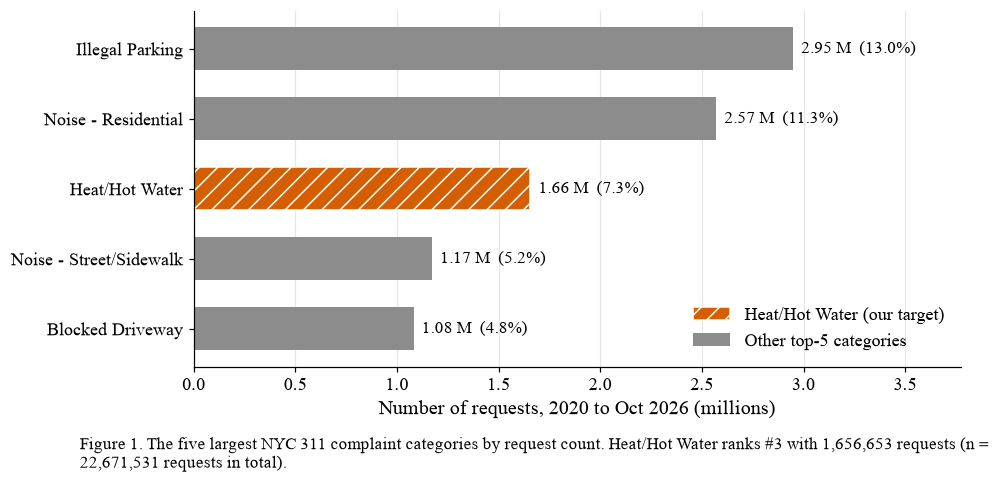

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))

# Largest category on top: reverse so barh draws it last.
plot_df = top.iloc[::-1]
colors = [VERMILION if flag else GREY for flag in plot_df["is_heating"]]
bars = ax.barh(
    [tidy_label(c) for c in plot_df["category"]],
    plot_df["n"] / 1e6,
    color=colors,
    height=0.62,
)

for bar, flag in zip(bars, plot_df["is_heating"]):
    if flag:
        bar.set_hatch("//")
        bar.set_edgecolor("white")

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    label = f"{row['n'] / 1e6:.2f} M  ({row['share']:.1f}%)"
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=11)

ax.set_xlim(0, top["n"].max() / 1e6 * 1.28)
ax.set_xlabel("Number of requests, 2020 to Oct 2026 (millions)")
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label="Heat/Hot Water (our target)"),
        Patch(facecolor=GREY, label="Other top-5 categories"),
    ],
    loc="lower right",
)

add_caption(
    fig,
    f"Figure 1. The five largest NYC 311 complaint categories by request count. "
    f"Heat/Hot Water ranks #{heating_rank} with {top.loc[top['is_heating'], 'n'].iloc[0]:,} requests "
    f"(n = {TOTAL_ROWS:,} requests in total).",
)
fig.savefig(FIG_DIR / "01_top5_categories.png")
plt.show()

**Reading Figure 1.** Heating is the third-largest complaint category in the whole city, ahead of street noise and blocked driveways.
It is large enough to model on its own, and it comes from a single agency (HPD) with a single, well-defined resolution process.

### 1.1 Where each top complaint comes from

**Question the figure answers:** *For the ten largest complaint categories, what share of requests comes from each borough?*

This needs one more pass over the 16 GB file, grouped by category, borough and year. It is cached like the category counts.

In [8]:
BOROUGH_YEAR_CACHE = DATA_DIR / "category_borough_year_counts.csv"


def load_category_borough_year_counts():
    """Rows per complaint category, borough and creation year. Cached, because it is another full scan of the CSV."""
    if BOROUGH_YEAR_CACHE.exists():
        return pd.read_csv(BOROUGH_YEAR_CACHE)

    query = f"""
        SELECT
            upper(trim("{CATEGORY_COL}")) AS category,
            upper(trim("Borough")) AS borough,
            year(try_strptime("Created Date", '%m/%d/%Y %I:%M:%S %p')) AS year,
            count(*) AS n
        FROM read_csv('{CSV_PATH}', header=true, all_varchar=true, ignore_errors=true, sample_size=-1)
        GROUP BY 1, 2, 3
    """
    table = duckdb.connect().execute(query).df()
    table.to_csv(BOROUGH_YEAR_CACHE, index=False)
    return table


category_borough_year = load_category_borough_year_counts()
assert int(category_borough_year["n"].sum()) == TOTAL_ROWS

in_a_borough = category_borough_year[category_borough_year["borough"].isin(BOROUGHS)]
no_borough_share = 100 - in_a_borough["n"].sum() / TOTAL_ROWS * 100
print(f"Requests with no valid borough (left out of the borough views): {no_borough_share:.2f}%")

Requests with no valid borough (left out of the borough views): 0.35%


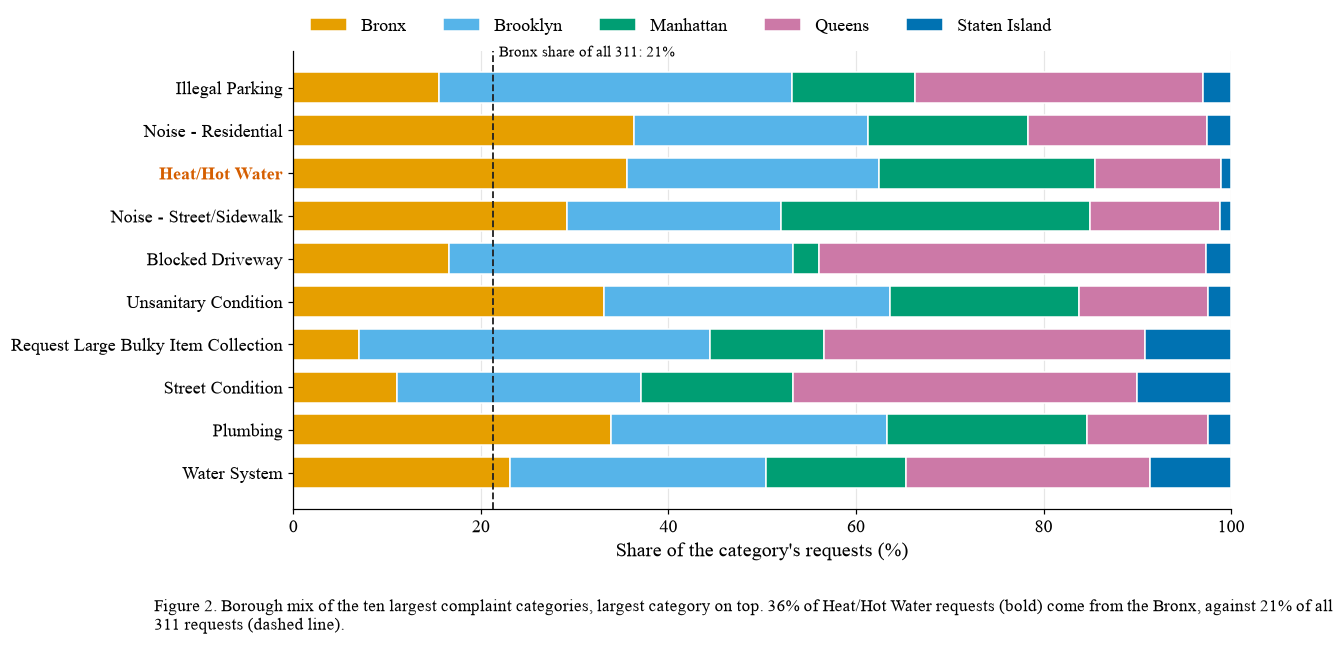

borough,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
category,,,,,
ILLEGAL PARKING,15.6,37.6,13.1,30.7,3.0
NOISE - RESIDENTIAL,36.4,24.9,17.0,19.1,2.6
HEAT/HOT WATER,35.5,26.9,23.1,13.4,1.1
NOISE - STREET/SIDEWALK,29.2,22.8,33.0,13.8,1.2
BLOCKED DRIVEWAY,16.6,36.7,2.8,41.3,2.7
UNSANITARY CONDITION,33.2,30.5,20.1,13.8,2.4
REQUEST LARGE BULKY ITEM COLLECTION,7.0,37.5,12.1,34.2,9.2
STREET CONDITION,11.0,26.0,16.2,36.7,10.0
PLUMBING,33.8,29.5,21.3,12.9,2.4


In [9]:
top10 = counts.head(10)["category"].tolist()
top10_by_borough = (
    in_a_borough[in_a_borough["category"].isin(top10)]
    .pivot_table(index="category", columns="borough", values="n", aggfunc="sum", fill_value=0)
    .reindex(index=top10, columns=BOROUGHS)
)
top10_share = top10_by_borough.div(top10_by_borough.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.4))
plot_share = top10_share.iloc[::-1]
labels = [tidy_label(c) for c in plot_share.index]
left = np.zeros(len(plot_share))
for borough in BOROUGHS:
    values = plot_share[borough].to_numpy()
    ax.barh(labels, values, left=left, color=BOROUGH_COLOURS[borough], edgecolor="white", height=0.72, label=borough.title())
    left = left + values

for tick in ax.get_yticklabels():
    if tick.get_text() == tidy_label(HEATING_CATEGORY):
        tick.set_fontweight("bold")
        tick.set_color(VERMILION)

heating_bronx = top10_share.loc[HEATING_CATEGORY, "BRONX"]
borough_totals = in_a_borough.groupby("borough")["n"].sum()
bronx_overall = borough_totals["BRONX"] / borough_totals.sum() * 100
ax.axvline(bronx_overall, color="#222222", linestyle="--", linewidth=1.2)
ax.text(bronx_overall + 0.6, len(plot_share) - 0.35, f"Bronx share of all 311: {bronx_overall:.0f}%", fontsize=10, va="bottom")
ax.set_xlim(0, 100)
ax.set_xlabel("Share of the category's requests (%)")
ax.grid(axis="y", visible=False)
ax.legend(ncol=5, loc="lower left", bbox_to_anchor=(0, 1.0))

add_caption(
    fig,
    f"Figure 2. Borough mix of the ten largest complaint categories, largest category on top. "
    f"{heating_bronx:.0f}% of Heat/Hot Water requests (bold) come from the Bronx, against {bronx_overall:.0f}% of all 311 requests (dashed line).",
)
fig.savefig(FIG_DIR / "02_top10_borough_share.png")
plt.show()

top10_share.round(1)

**Reading Figure 2.** The Bronx files about 36% of heating requests but only about 21% of all 311 requests; only residential noise is
as Bronx-heavy. Staten Island barely appears (1%). So borough is a natural feature, and any citywide statistic of heating is pulled
towards the Bronx.

### 1.2 How the top categories changed over the years

**Question the figure answers:** *Did yearly volume of the five largest categories rise or fall, and in which borough?*
2026 is left out because it covers only January to September.

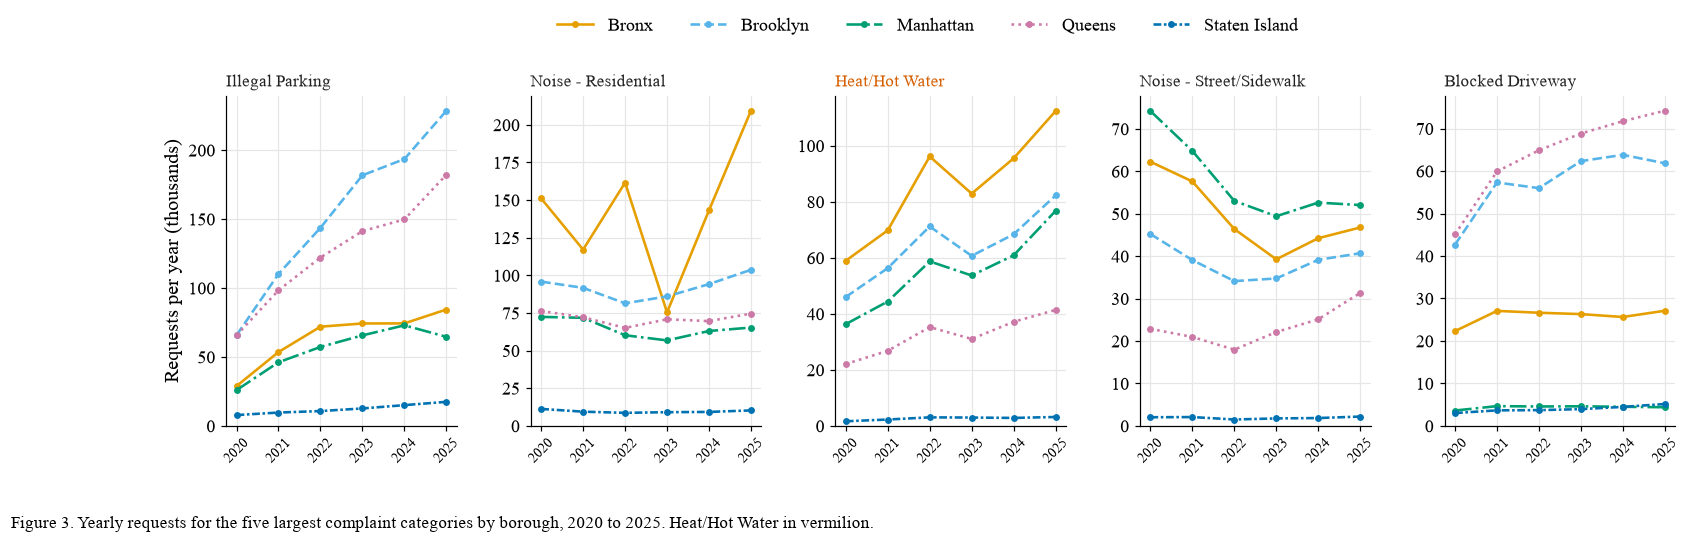

In [10]:
top5_categories = counts.head(5)["category"].tolist()
full_years = in_a_borough[in_a_borough["year"].between(2020, 2025)].copy()
full_years["year"] = full_years["year"].astype(int)
years = list(range(2020, 2026))

fig, axes = plt.subplots(1, 5, figsize=(17, 3.9), gridspec_kw={"wspace": 0.32})
for ax, category in zip(axes, top5_categories):
    subset = full_years[full_years["category"] == category]
    yearly = subset.pivot_table(index="year", columns="borough", values="n", aggfunc="sum").reindex(index=years, columns=BOROUGHS)
    for borough in BOROUGHS:
        ax.plot(
            yearly.index,
            yearly[borough] / 1000,
            color=BOROUGH_COLOURS[borough],
            linestyle=BOROUGH_STYLES[borough],
            marker="o",
            markersize=3.5,
            linewidth=1.7,
            label=borough.title(),
        )
    title_colour = VERMILION if category == HEATING_CATEGORY else "#222222"
    ax.set_title(tidy_label(category), loc="left", fontsize=11, color=title_colour)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, fontsize=9)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel("Requests per year (thousands)")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.1))
add_caption(fig, "Figure 3. Yearly requests for the five largest complaint categories by borough, 2020 to 2025. Heat/Hot Water in vermilion.", y=-0.1)
fig.savefig(FIG_DIR / "03_top5_yearly_by_borough.png")
plt.show()

**Reading Figure 3.** Heating volume roughly doubles from 2020 to 2025 in every borough (with a dip in 2023), and the Bronx stays the
largest source every year (59k requests in 2020, 112k in 2025).
A growing volume with a fixed inspection staff is one reason resolution time can drift between years (section 10.3).

## 2. Keep only heating requests

**Decision.** Keep rows where the upper-cased `Problem` equals `HEAT/HOT WATER`. Drop every other row.

**Why.**
- The project predicts heating resolution time only. Other categories have different agencies, processes and timescales, so mixing them would blur the target.
- Matching on the upper-cased label keeps the 1,814 rows that were typed `Heat/Hot Water` in Aug to Oct 2023.
- `Non-Residential Heat` (DOHMH) is a different category with a different process, so this rule removes it too.

**How.** DuckDB filters the 16 GB file and writes the kept rows to Parquet. Every column stays as raw text for now,
because type conversion is a cleaning step we do later and document there.

In [11]:
def extract_heating_rows():
    """Filter the big CSV down to heating rows once and cache them as Parquet."""
    if HEATING_PARQUET.exists():
        return

    query = f"""
        COPY (
            SELECT *
            FROM read_csv('{CSV_PATH}', header=true, all_varchar=true, ignore_errors=true, sample_size=-1)
            WHERE upper(trim("{CATEGORY_COL}")) = '{HEATING_CATEGORY}'
        ) TO '{HEATING_PARQUET}' (FORMAT parquet)
    """
    duckdb.connect().execute(query)


extract_heating_rows()
heating = pd.read_parquet(HEATING_PARQUET)
print(f"Kept {len(heating):,} rows x {heating.shape[1]} columns")

Kept 1,656,653 rows x 44 columns


In [12]:
expected = int(counts.loc[counts["category"] == HEATING_CATEGORY, "n"].iloc[0])
assert len(heating) == expected, f"row count {len(heating):,} does not match category count {expected:,}"

kept = len(heating)
dropped = TOTAL_ROWS - kept
print(f"Before: {TOTAL_ROWS:,} rows")
print(f"After:  {kept:,} rows ({kept / TOTAL_ROWS * 100:.1f}% kept)")
print(f"Dropped: {dropped:,} rows from {len(counts) - 1} other categories")

Before: 22,671,531 rows
After:  1,656,653 rows (7.3% kept)
Dropped: 21,014,878 rows from 260 other categories


### Before and after

**Question the figure answers:** *How many rows did the filter remove, and which categories did they come from?*

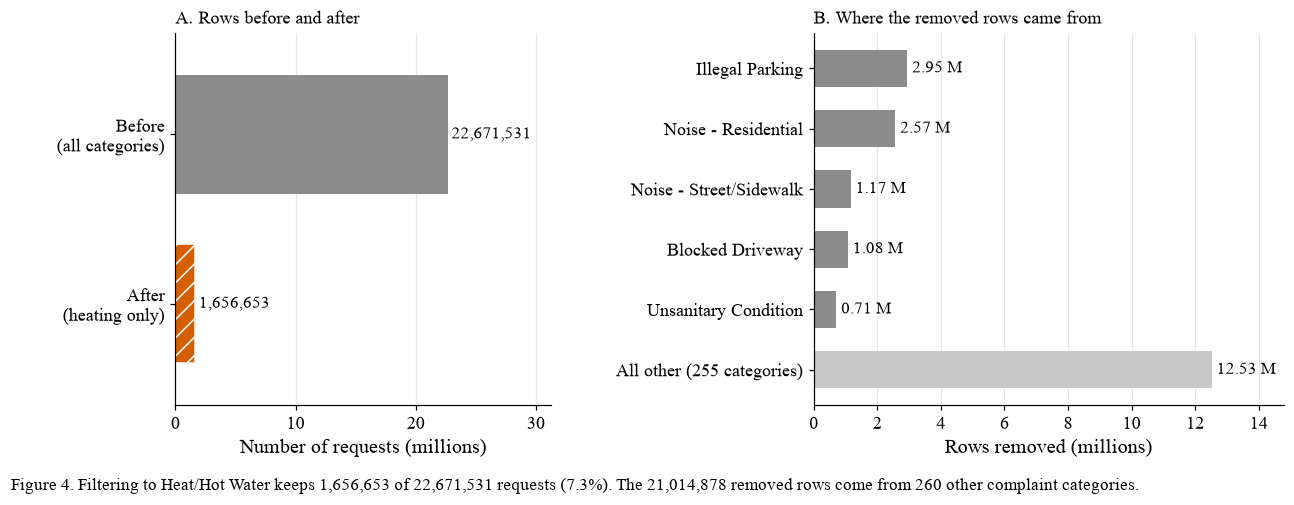

In [13]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.62})

# Panel A: row count before and after, zero baseline.
ax_a.barh(
    ["After\n(heating only)", "Before\n(all categories)"],
    [kept / 1e6, TOTAL_ROWS / 1e6],
    color=[VERMILION, GREY],
    height=0.7,
)
ax_a.patches[0].set_hatch("//")
ax_a.patches[0].set_edgecolor("white")
for patch, value in zip(ax_a.patches, [kept, TOTAL_ROWS]):
    ax_a.text(patch.get_width() + 0.3, patch.get_y() + patch.get_height() / 2, f"{value:,}", va="center", fontsize=11)
ax_a.set_xlim(0, TOTAL_ROWS / 1e6 * 1.38)
ax_a.set_ylim(-0.6, 1.6)
ax_a.set_xlabel("Number of requests (millions)")
ax_a.grid(axis="y", visible=False)
ax_a.set_title("A. Rows before and after", loc="left", fontsize=12)

# Panel B: what was removed, largest first, 'all other' last.
removed = counts[counts["category"] != HEATING_CATEGORY].copy()
largest = removed.head(5)
rest = removed.iloc[5:]["n"].sum()
labels = [tidy_label(c) for c in largest["category"]] + [f"All other ({len(removed) - 5} categories)"]
values = list(largest["n"] / 1e6) + [rest / 1e6]
bar_colors = [GREY] * 5 + ["#C8C8C8"]

positions = np.arange(len(labels))[::-1]
ax_b.barh(positions, values, color=bar_colors, height=0.62)
ax_b.set_yticks(positions)
ax_b.set_yticklabels(labels)
for pos, value in zip(positions, values):
    ax_b.text(value + 0.15, pos, f"{value:.2f} M", va="center", fontsize=11)
ax_b.set_xlim(0, max(values) * 1.18)
ax_b.set_xlabel("Rows removed (millions)")
ax_b.grid(axis="y", visible=False)
ax_b.set_title("B. Where the removed rows came from", loc="left", fontsize=12)

add_caption(
    fig,
    f"Figure 4. Filtering to Heat/Hot Water keeps {kept:,} of {TOTAL_ROWS:,} requests ({kept / TOTAL_ROWS * 100:.1f}%). "
    f"The {dropped:,} removed rows come from {len(removed)} other complaint categories.",
)
fig.savefig(FIG_DIR / "04_filter_to_heating_before_after.png")
plt.show()

## 3. The heating-only dataset

From here on, `heating` is the working dataset. First look at its structure.

In [14]:
heating.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,70607308,10/01/2026 11:58:54 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,NO HOT WATER,RESIDENTIAL BUILDING,10467,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.87711548073,-73.87314137787,POINT (-73.873141377875 40.877115480725)
1,70615467,10/01/2026 11:41:10 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11355,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.75423566298,-73.83142702295,POINT (-73.831427022953 40.754235662982)
2,70613895,10/01/2026 11:31:41 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.76830976173,-73.98662439013,POINT (-73.986624390128 40.76830976173)
3,70608878,10/01/2026 11:31:30 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.65595860808,-73.95490586002,POINT (-73.954905860019 40.655958608083)
4,70608877,10/01/2026 11:26:06 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.82946158953,-73.94079691863,POINT (-73.940796918633 40.829461589532)


In [15]:
heating.shape

(1656653, 44)

## 4. Cleaning step 1: redundant structure

**Question this step answers:** *Which columns and rows add nothing, so they can go before we analyse anything?*

Order matters (Lecture 4): **drop the ID column first**, because a unique ID makes `duplicated()` unable to ever fire.
Then count and drop duplicate rows. Then drop columns that hold a single value, columns that are exact copies of another column, and columns that can be rebuilt from another column.

### 4.1 The ID column: `Unique Key`

`Unique Key` is a serial number NYC assigns to every request. It carries no information about resolution time,
and it hides duplicates, because two otherwise identical requests still get different keys.

In [16]:
ID_COL = "Unique Key"

print(f"{ID_COL}: {heating[ID_COL].nunique():,} distinct values for {len(heating):,} rows, so every row has its own ID")
print(f"duplicated() with the ID:    {heating.duplicated().sum():,}")
print(f"duplicated() without the ID: {heating.drop(columns=[ID_COL]).duplicated().sum():,}")

Unique Key: 1,656,653 distinct values for 1,656,653 rows, so every row has its own ID


duplicated() with the ID:    0


duplicated() without the ID: 3,128


**Decision.** Drop `Unique Key`. The check above shows why: with the ID the duplicate count is 0, without it the real count appears.
`clean` is the working copy from here on; `heating` stays untouched as the "before" reference for every before/after figure.

In [17]:
clean = heating.drop(columns=[ID_COL])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,656,653 rows x 43 columns


### 4.2 Duplicate rows

A row is an **exact duplicate** when every remaining column matches an earlier row, down to the second in `Created Date` and `Closed Date`.
`keep="first"` keeps one copy of each. Because the copies are identical, it does not matter which one is kept.

In [18]:
DATE_FORMAT = "%m/%d/%Y %I:%M:%S %p"
CHANNEL_COL = "Open Data Channel Type"


def resolution_hours(frame):
    """Hours between Created Date and Closed Date. Only used here to check what a drop does to the target."""
    created = pd.to_datetime(frame["Created Date"], format=DATE_FORMAT)
    closed = pd.to_datetime(frame["Closed Date"], format=DATE_FORMAT)
    return (closed - created).dt.total_seconds() / 3600

In [19]:
is_duplicate = clean.duplicated(keep="first")
n_duplicates = int(is_duplicate.sum())
all_copies = clean[clean.duplicated(keep=False)]

group_sizes = all_copies.groupby(list(all_copies.columns), dropna=False).size()
size_table = group_sizes.value_counts().sort_index().rename_axis("copies of the same row").rename("groups")

print(f"Exact duplicate rows to remove: {n_duplicates:,} ({n_duplicates / len(clean) * 100:.2f}% of rows)")
print(f"Rows involved, including the copy we keep: {len(all_copies):,} in {len(group_sizes):,} groups")
size_table

Exact duplicate rows to remove: 3,128 (0.19% of rows)
Rows involved, including the copy we keep: 6,160 in 3,032 groups


copies of the same row
2    2942
3      85
4       4
5       1
Name: groups, dtype: int64

**Are these real duplicates or two genuine complaints?** The same request submitted twice in the same second is a double-tap on "submit".
Two different tenants filing at the very same second, for the same address, with the same answer and close time, would be a coincidence.
If these are double-taps, the mobile app should be heavily over-represented among them.

In [20]:
channel_all = clean[CHANNEL_COL].value_counts(normalize=True) * 100
channel_removed = clean.loc[is_duplicate, CHANNEL_COL].value_counts(normalize=True) * 100
channel_removed = channel_removed.reindex(channel_all.index, fill_value=0)

channel_table = pd.DataFrame({"all rows (%)": channel_all.round(1), "removed duplicates (%)": channel_removed.round(1)})
channel_table

,all rows (%),removed duplicates (%)
Open Data Channel Type,,
ONLINE,53.7,28.3
PHONE,28.1,2.1
MOBILE,18.2,69.6


**Decision.** Drop the exact duplicates, keeping the first copy.

**Why.** They are repeated submissions of one request, and keeping them would count that request twice in every average and model fit.

**Not dropped.** Rows that match on address and creation second but differ elsewhere (for example a different `Closed Date`) are
different complaints, such as separate apartments in one building. We cannot tell them apart from the data, so they stay.

In [21]:
rows_before = len(clean)
hours_before = resolution_hours(clean)

clean = clean[~is_duplicate].reset_index(drop=True)
hours_after = hours_before[~is_duplicate]

assert clean.duplicated().sum() == 0
assert rows_before - len(clean) == n_duplicates
print(f"{rows_before:,} rows -> {len(clean):,} rows (removed {n_duplicates:,})")

1,656,653 rows -> 1,653,525 rows (removed 3,128)


### Before and after

**Question the figure answers:** *Which rows did the duplicate drop remove, and did it change the target?*

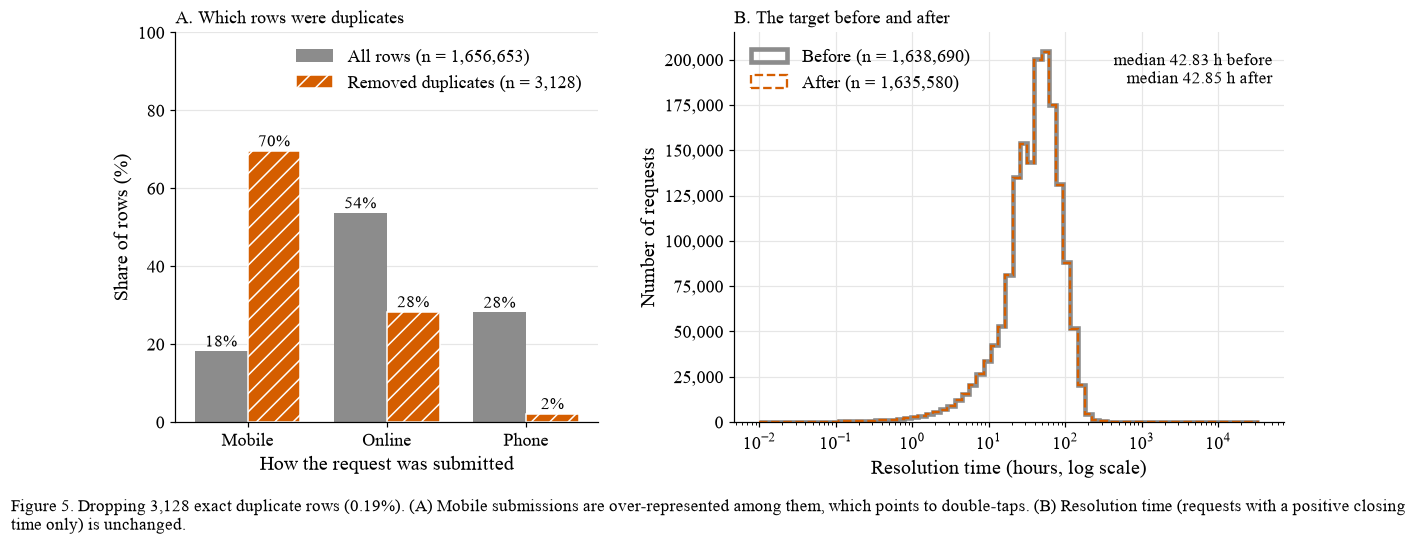

In [22]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.3], "wspace": 0.28})

# Panel A: channel mix of the removed rows against all rows, same zero baseline.
order = list(channel_removed.sort_values(ascending=False).index)
positions = np.arange(len(order))
bar_width = 0.38

ax_a.bar(positions - bar_width / 2, [channel_all[c] for c in order], bar_width, color=GREY)
ax_a.bar(
    positions + bar_width / 2,
    [channel_removed[c] for c in order],
    bar_width,
    color=VERMILION,
    hatch="//",
    edgecolor="white",
)
for pos, channel in zip(positions, order):
    ax_a.text(pos - bar_width / 2, channel_all[channel] + 1.2, f"{channel_all[channel]:.0f}%", ha="center", fontsize=11)
    ax_a.text(pos + bar_width / 2, channel_removed[channel] + 1.2, f"{channel_removed[channel]:.0f}%", ha="center", fontsize=11)

ax_a.set_xticks(positions)
ax_a.set_xticklabels([c.title() for c in order])
ax_a.set_ylim(0, 100)
ax_a.set_ylabel("Share of rows (%)")
ax_a.set_xlabel("How the request was submitted")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Which rows were duplicates", loc="left", fontsize=12)
ax_a.legend(
    handles=[
        Patch(facecolor=GREY, label=f"All rows (n = {rows_before:,})"),
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label=f"Removed duplicates (n = {n_duplicates:,})"),
    ],
    loc="upper right",
)

# Panel B: resolution time before and after, one axis so the curves can be compared directly.
positive_before = hours_before[hours_before > 0].dropna()
positive_after = hours_after[hours_after > 0].dropna()
bins = np.logspace(-2, np.log10(positive_before.max()), 70)

ax_b.hist(positive_before, bins=bins, histtype="step", color=GREY, linewidth=3.0, label=f"Before (n = {len(positive_before):,})")
ax_b.hist(positive_after, bins=bins, histtype="step", color=VERMILION, linewidth=1.5, linestyle="--", label=f"After (n = {len(positive_after):,})")
ax_b.set_xscale("log")
ax_b.set_xlabel("Resolution time (hours, log scale)")
ax_b.set_ylabel("Number of requests")
ax_b.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax_b.set_title("B. The target before and after", loc="left", fontsize=12)
ax_b.legend(loc="upper left")
ax_b.text(
    0.98,
    0.95,
    f"median {positive_before.median():.2f} h before\nmedian {positive_after.median():.2f} h after",
    transform=ax_b.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)

add_caption(
    fig,
    f"Figure 5. Dropping {n_duplicates:,} exact duplicate rows ({n_duplicates / rows_before * 100:.2f}%). "
    f"(A) Mobile submissions are over-represented among them, which points to double-taps. "
    f"(B) Resolution time (requests with a positive closing time only) is unchanged.",
)
fig.savefig(FIG_DIR / "05_duplicate_rows_before_after.png")
plt.show()

In [23]:
summary = pd.DataFrame(
    {
        "rows": [rows_before, len(clean)],
        "median (h)": [hours_before.median(), hours_after.median()],
        "mean (h)": [hours_before.mean(), hours_after.mean()],
        "90th pct (h)": [hours_before.quantile(0.9), hours_after.quantile(0.9)],
    },
    index=["before", "after"],
)
summary.round(2)

,rows,median (h),mean (h),90th pct (h)
before,1656653,42.82,50.89,95.01
after,1653525,42.84,50.92,95.04


**Reading Figure 5.** The removed rows are mostly mobile-app submissions, which supports the double-tap explanation.
The target distribution does not move, so this drop is safe. It is still the right thing to do for counting and for model training.

### 4.3 Columns that hold a single value

A column with the same value in every row cannot help predict anything, because it never varies.

Four columns should be like this:
- `Agency` and `Agency Name`: every row is handled by HPD.
- `Park Facility Name`: a placeholder for park complaints, which heating is not.
- `Problem (formerly Complaint Type)`: we filtered on it in section 2, so it has one value by construction.

The code checks this instead of assuming it. Values are upper-cased and trimmed first, because `Problem` is spelled
`HEAT/HOT WATER` in most rows and `Heat/Hot Water` in 1,814 rows, and those are the same value.

In [24]:
CONSTANT_CANDIDATES = [
    "Agency",
    "Agency Name",
    "Park Facility Name",
    "Problem (formerly Complaint Type)",
]

constant_cols = []
for col in CONSTANT_CANDIDATES:
    raw_distinct = clean[col].nunique(dropna=False)
    normalised = clean[col].str.strip().str.upper()
    normalised_distinct = normalised.nunique(dropna=False)
    only_value = normalised.iloc[0]

    print(f"{col}")
    print(f"    distinct values as written: {raw_distinct}")
    print(f"    distinct values after upper-casing: {normalised_distinct}  (value: {only_value!r})")

    if normalised_distinct == 1:
        constant_cols.append(col)

Agency
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'HPD')
Agency Name
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'DEPARTMENT OF HOUSING PRESERVATION AND DEVELOPMENT')


Park Facility Name
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'UNSPECIFIED')
Problem (formerly Complaint Type)
    distinct values as written: 2
    distinct values after upper-casing: 1  (value: 'HEAT/HOT WATER')


**Decision.** All four have exactly one value in every row, so each is dropped.

**Why.** A column that never changes has no relationship with resolution time, and it only adds width to the data.

In [25]:
columns_before = clean.shape[1]
clean = clean.drop(columns=constant_cols)

print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 4 constant columns: ['Agency', 'Agency Name', 'Park Facility Name', 'Problem (formerly Complaint Type)']
clean: 1,653,525 rows x 39 columns (was 43)


### 4.4 Columns that are copies of another column

**The problem.** Three columns look like separate fields, but their names suggest they repeat another column:

| Possible copy | Possible original |
|---|---|
| `Intersection Street 1` | `Cross Street 1` |
| `Intersection Street 2` | `Cross Street 2` |
| `Park Borough` | `Borough` |

A copy adds no information, and it counts the same signal twice in any correlation matrix or model.

**The rule.** If a column shares *all* of its values with its partner, in every row (a blank in both counts as a match), drop the copy and keep the original.
If even a few rows differ, the column carries something extra and stays.

In [26]:
COPY_PAIRS = [
    ("Cross Street 1", "Intersection Street 1"),
    ("Cross Street 2", "Intersection Street 2"),
    ("Borough", "Park Borough"),
]

copy_cols = []
for original, copy in COPY_PAIRS:
    same = clean[original].fillna("<missing>").eq(clean[copy].fillna("<missing>"))
    n_same = int(same.sum())
    print(f"{copy!r} matches {original!r} in {n_same:,} of {len(clean):,} rows")

    if same.all():
        copy_cols.append(copy)

'Intersection Street 1' matches 'Cross Street 1' in 1,653,525 of 1,653,525 rows
'Intersection Street 2' matches 'Cross Street 2' in 1,653,525 of 1,653,525 rows
'Park Borough' matches 'Borough' in 1,653,525 of 1,653,525 rows


**Decision.** Each of the three matches its partner in every row, so the copy is dropped and the original kept.

**Why.** Nothing is lost, because the original column holds exactly the same values.

In [27]:
columns_before = clean.shape[1]
clean = clean.drop(columns=copy_cols)

print(f"Dropped {len(copy_cols)} copy columns: {copy_cols}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 3 copy columns: ['Intersection Street 1', 'Intersection Street 2', 'Park Borough']
clean: 1,653,525 rows x 36 columns (was 39)


### 4.5 `Address Type`

`Address Type` records how NYC matched the address (for example `ADDRESS` or `INTERSECTION`).
Every heating request is filed against a building address, so it should be the same value throughout.

In [28]:
address_type_counts = clean["Address Type"].value_counts(dropna=False)
top_value = address_type_counts.index[0]
top_share = address_type_counts.iloc[0] / len(clean) * 100

print(f"{top_value!r} in {address_type_counts.iloc[0]:,} of {len(clean):,} rows ({top_share:.4f}%)")
address_type_counts

'ADDRESS' in 1,653,522 of 1,653,525 rows (99.9998%)


Address Type
ADDRESS         1653522
NaN                   2
UNRECOGNIZED          1
Name: count, dtype: int64

**Decision.** Drop `Address Type`.

**Why.** It is `ADDRESS` in every row except a handful (the counts above show exactly which: blanks and one `UNRECOGNIZED`).
A column that is the same for essentially every request cannot explain why one request is resolved faster than another.
Dropping the column does not remove those rows.

In [29]:
clean = clean.drop(columns=["Address Type"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 35 columns


### 4.6 `Location`

**The problem.** `Location` looks like a separate location field, but it is the `Latitude` and `Longitude` columns written as one piece of text.

**How it is derived.** `Location` is the text `POINT (longitude latitude)`. Reading the two numbers back out of the brackets
gives `Longitude` first and `Latitude` second, the same values as the two columns. The only difference is rounding:
`Location` keeps 12 decimals and the other two columns keep 11.

In [30]:
clean[["Latitude", "Longitude", "Location"]].head(3)

,Latitude,Longitude,Location
0,40.87711548073,-73.87314137787,POINT (-73.873141377875 40.877115480725)
1,40.75423566298,-73.83142702295,POINT (-73.831427022953 40.754235662982)
2,40.76830976173,-73.98662439013,POINT (-73.986624390128 40.76830976173)


In [31]:
latitude = pd.to_numeric(clean["Latitude"])
longitude = pd.to_numeric(clean["Longitude"])

# The pattern pulls out the number after "POINT (" and the number before ")".
point = clean["Location"].str.extract(r"POINT \((-?[\d.]+) (-?[\d.]+)\)").astype(float)
longitude_from_location = point[0]
latitude_from_location = point[1]

largest_gap = max(
    (longitude_from_location - longitude).abs().max(),
    (latitude_from_location - latitude).abs().max(),
)
blank_in_same_rows = bool(longitude_from_location.isna().equals(longitude.isna()))

print(f"Largest difference between Location and Latitude/Longitude: {largest_gap:.1e} degrees")
print(f"Location is blank in exactly the rows where Latitude/Longitude are blank: {blank_in_same_rows}")

Largest difference between Location and Latitude/Longitude: 5.0e-12 degrees
Location is blank in exactly the rows where Latitude/Longitude are blank: True


**Decision.** Drop `Location`; keep `Latitude` and `Longitude`.

**Why.** The largest difference is about 5e-12 degrees, which is rounding at the 12th decimal place (under a millimetre),
and the blank rows match exactly. Nothing is lost. Two numeric columns are also easier to use than text that has to be parsed.

In [32]:
clean = clean.drop(columns=["Location"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 34 columns


### 4.7 `Location Type`

`Location Type` should describe where in a building the problem is. For almost every heating request it says the same thing,
and where it does differ it only repeats `Problem Detail`.

In [33]:
location_type_counts = clean["Location Type"].value_counts()
dominant_value = location_type_counts.index[0]
dominant_share = location_type_counts.iloc[0] / len(clean) * 100

print(f"{dominant_value!r} in {location_type_counts.iloc[0]:,} of {len(clean):,} rows ({dominant_share:.2f}%)")
location_type_counts

'RESIDENTIAL BUILDING' in 1,651,711 of 1,653,525 rows (99.89%)


Location Type
RESIDENTIAL BUILDING    1651711
Building-Wide              1103
Apartment                   711
Name: count, dtype: int64

In [34]:
# The few rows that differ: what does Problem Detail say for them?
detail_col = "Problem Detail (formerly Descriptor)"
differs = clean["Location Type"] != dominant_value

pd.crosstab(
    clean.loc[differs, "Location Type"].str.upper(),
    clean.loc[differs, detail_col].str.upper(),
)

Problem Detail (formerly Descriptor),APARTMENT ONLY,ENTIRE BUILDING,WATER SUPPLY
Location Type,,,
APARTMENT,559,152,0
BUILDING-WIDE,0,1102,1


**Decision.** Drop `Location Type`.

**Why.** It is `RESIDENTIAL BUILDING` in almost every row, so it does not vary. In the remaining rows
(created in the Aug to Oct 2023 window) it only restates `Problem Detail`: `Apartment` goes with `Apartment Only`
and `Building-Wide` goes with `Entire Building`. Either way, `Problem Detail` already holds the information.

In [35]:
clean = clean.drop(columns=["Location Type"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 33 columns


## 5. Cleaning step 2: numbers and dates stored as text

**Question this step answers:** *Are any numbers or dates stored as text, so that pandas cannot compute with them?*

Everything was loaded as text on purpose. The standard check is `info()` (types and non-blank counts) and `describe()`
(summary statistics of the numeric columns).

In [36]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1653525 entries, 0 to 1653524
Data columns (total 33 columns):
 #   Column                                Non-Null Count    Dtype
---  ------                                --------------    -----
 0   Created Date                          1653525 non-null  str  
 1   Closed Date                           1635871 non-null  str  
 2   Problem Detail (formerly Descriptor)  1653525 non-null  str  
 3   Additional Details                    1653525 non-null  str  
 4   Incident Zip                          1653335 non-null  str  
 5   Incident Address                      1653520 non-null  str  
 6   Street Name                           1653520 non-null  str  
 7   Cross Street 1                        1808 non-null     str  
 8   Cross Street 2                        1812 non-null     str  
 9   City                                  1653373 non-null  str  
 10  Landmark                              1812 non-null     str  
 11  Facility Type         

In [37]:
clean.describe().T

,count,unique,top,freq
Created Date,1653525,1574916,12/27/2024 01:40:15 PM,5
Closed Date,1635871,553427,10/03/2023 12:00:00 AM,363
Problem Detail (formerly Descriptor),1653525,5,ENTIRE BUILDING,1082238
Additional Details,1653525,8,NO HEAT,956509
Incident Zip,1653335,209,11226,51307
Incident Address,1653520,100145,2176 TIEBOUT AVENUE,15171
Street Name,1653520,5039,GRAND CONCOURSE,28249
Cross Street 1,1808,590,2 AVENUE,83
Cross Street 2,1812,580,1 AVENUE,86
City,1653373,89,BRONX,587119


**What the two outputs show.**
- `info()` lists every one of the 33 columns as text (`str`).
- `describe()` has no numeric column to summarise. Instead of `mean`, `min` and `max`, it falls back to `unique`, `top` and `freq`,
  so it cannot give any statistics for the columns that really are numbers (Lecture 4, "Trap 1").

**Numbers stored as text.** Four columns are obviously measurements: `Latitude`, `Longitude`, and the two State Plane coordinates
`X Coordinate (State Plane)` and `Y Coordinate (State Plane)`. The State Plane values also contain thousands commas (`1,019,332`).

**Dates stored as text.** `Created Date`, `Closed Date` and `Resolution Action Updated Date` are timestamps in the format
`MM/DD/YYYY hh:mm:ss AM/PM`.

**Digits that are not numbers.** `Incident Zip`, `Council District` and `BBL` are made of digits, but they are labels for a place,
not measurements, so they stay as text. `Due Date` is a date column but it is completely empty, so there is nothing to convert.

In [38]:
FLOAT_COLS = ["Latitude", "Longitude", "X Coordinate (State Plane)", "Y Coordinate (State Plane)"]
DATE_COLS = ["Created Date", "Closed Date", "Resolution Action Updated Date"]

nonblank_before = clean[FLOAT_COLS + DATE_COLS].notna().sum()

In [39]:
for col in FLOAT_COLS:
    without_commas = clean[col].str.replace(",", "", regex=False)
    clean[col] = pd.to_numeric(without_commas, errors="raise")

In [40]:
for col in DATE_COLS:
    clean[col] = pd.to_datetime(clean[col], format=DATE_FORMAT)

In [41]:
nonblank_after = clean[FLOAT_COLS + DATE_COLS].notna().sum()
assert (nonblank_after == nonblank_before).all()
print("Every converted column has the same number of non-blank values as before.")

Every converted column has the same number of non-blank values as before.


In [42]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1653525 entries, 0 to 1653524
Data columns (total 33 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   Created Date                          1653525 non-null  datetime64[us]
 1   Closed Date                           1635871 non-null  datetime64[us]
 2   Problem Detail (formerly Descriptor)  1653525 non-null  str           
 3   Additional Details                    1653525 non-null  str           
 4   Incident Zip                          1653335 non-null  str           
 5   Incident Address                      1653520 non-null  str           
 6   Street Name                           1653520 non-null  str           
 7   Cross Street 1                        1808 non-null     str           
 8   Cross Street 2                        1812 non-null     str           
 9   City                                  1653373 non-null  s

In [43]:
clean[FLOAT_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,1653337.0,4.076785e+01,0.088558,40.500300,40.682304,4.079981e+01,4.084518e+01,4.091229e+01
Longitude,1653337.0,-7.391797e+01,0.054398,-74.250801,-73.951493,-7.392093e+01,-7.388784e+01,-7.370074e+01
X Coordinate (State Plane),1653337.0,1.006964e+06,15071.966976,914513.000000,997691.000000,1.006137e+06,1.015294e+06,1.067177e+06
Y Coordinate (State Plane),1653337.0,2.190393e+05,32266.028285,121644.000000,187885.000000,2.306720e+05,2.472200e+05,2.716640e+05


In [44]:
clean[DATE_COLS].describe().T

,count,mean,min,25%,50%,75%,max
Created Date,1653525,2023-09-10 18:21:11.378138,2020-01-01 00:04:45,2022-01-26 16:20:05,2023-12-05 05:55:10,2025-03-10 00:16:38,2026-10-01 23:58:54
Closed Date,1635871,2023-09-05 00:16:44.594120,2020-01-01 17:21:51,2022-01-27 10:18:25,2023-11-30 21:55:03,2025-03-02 22:52:44,2026-10-01 23:31:00
Resolution Action Updated Date,1653348,2023-09-12 09:27:46.543130,2020-01-01 17:21:51,2022-01-29 00:00:00,2023-12-06 00:00:00,2025-03-11 00:00:00,2026-10-01 23:31:00


**Changes made.**

| Columns | Before | After | How |
|---|---|---|---|
| `Latitude`, `Longitude` | text | float64 | `pd.to_numeric` |
| `X Coordinate (State Plane)`, `Y Coordinate (State Plane)` | text | float64 | thousands commas removed, then `pd.to_numeric` |
| `Created Date`, `Closed Date`, `Resolution Action Updated Date` | text | datetime64 | `pd.to_datetime` with the exact format |

Both conversions used strict settings (`errors="raise"` for numbers, an exact format for dates), so a value that did not fit would have stopped the cell.
None did, and every converted column has the same number of non-blank values as before (checked by the assertion).

`describe()` now returns one row for each of the four numeric columns, matching the number of numeric columns we expect (Lecture 4's rule),
and the date columns now have a real earliest and latest timestamp.
No rows or columns were removed in this step.

## 6. Cleaning step 3: missing data

**Question this step answers:** *Which columns have missing values, how many, and why?*

Lecture 4 warns that missing data comes in three disguises, and `isna()` only sees the first:

| Disguise | Example | Seen by `isna()`? |
|---|---|---|
| 1. Marked as missing | `NaN`, `NaT`, blank | Yes |
| 2. A string standing in for a value | `"Unspecified"`, `"N/A"` | No |
| 3. A legal value that is impossible | a closing time before the opening time | No |

This section does three things: chart the missing rate of every column, drop the columns that are completely empty,
and report on the rest. The percentage rule (drop, impute or keep) is applied afterwards.

### 6.1 How much is missing, column by column

**Question the figure answers:** *Which columns are missing values, and are any of them past the 30% line where the lecture says to consider dropping the column?*

The bands follow the lecture's rule: under 5% is a small problem, 5 to 30% needs care, and over 30% means the column is unreliable.

In [45]:
def missing_percent(frame):
    """Percent of missing values (NaN or NaT) in each column, largest first."""
    return (frame.isna().mean() * 100).sort_values(ascending=False)


def percent_label(value):
    """Format a percentage so that tiny values stay readable."""
    if value == 0:
        return "0%"
    if value >= 10:
        return f"{value:.1f}%"
    if value >= 0.01:
        return f"{value:.2f}%"
    return "<0.01%"


missing_before = missing_percent(clean)
columns_total = clean.shape[1]
missing_before.head(14).round(3)

Road Ramp                   100.000
Facility Type               100.000
Taxi Pick Up Location       100.000
Bridge Highway Name         100.000
Bridge Highway Direction    100.000
Due Date                    100.000
Taxi Company Borough        100.000
Vehicle Type                100.000
Bridge Highway Segment      100.000
Cross Street 1               99.891
Cross Street 2               99.890
Landmark                     99.890
Closed Date                   1.068
BBL                           0.411
dtype: float64

In [46]:
# Isna() cannot see text that is only spaces, so check that no column has any.
text_columns = [
    col
    for col in clean.columns
    if not pd.api.types.is_numeric_dtype(clean[col]) and not pd.api.types.is_datetime64_any_dtype(clean[col])
]
whitespace_only = sum(int((clean[col].dropna().str.strip() == "").sum()) for col in text_columns)
print(f"Values that are only whitespace, across {len(text_columns)} text columns: {whitespace_only}")

Values that are only whitespace, across 26 text columns: 0


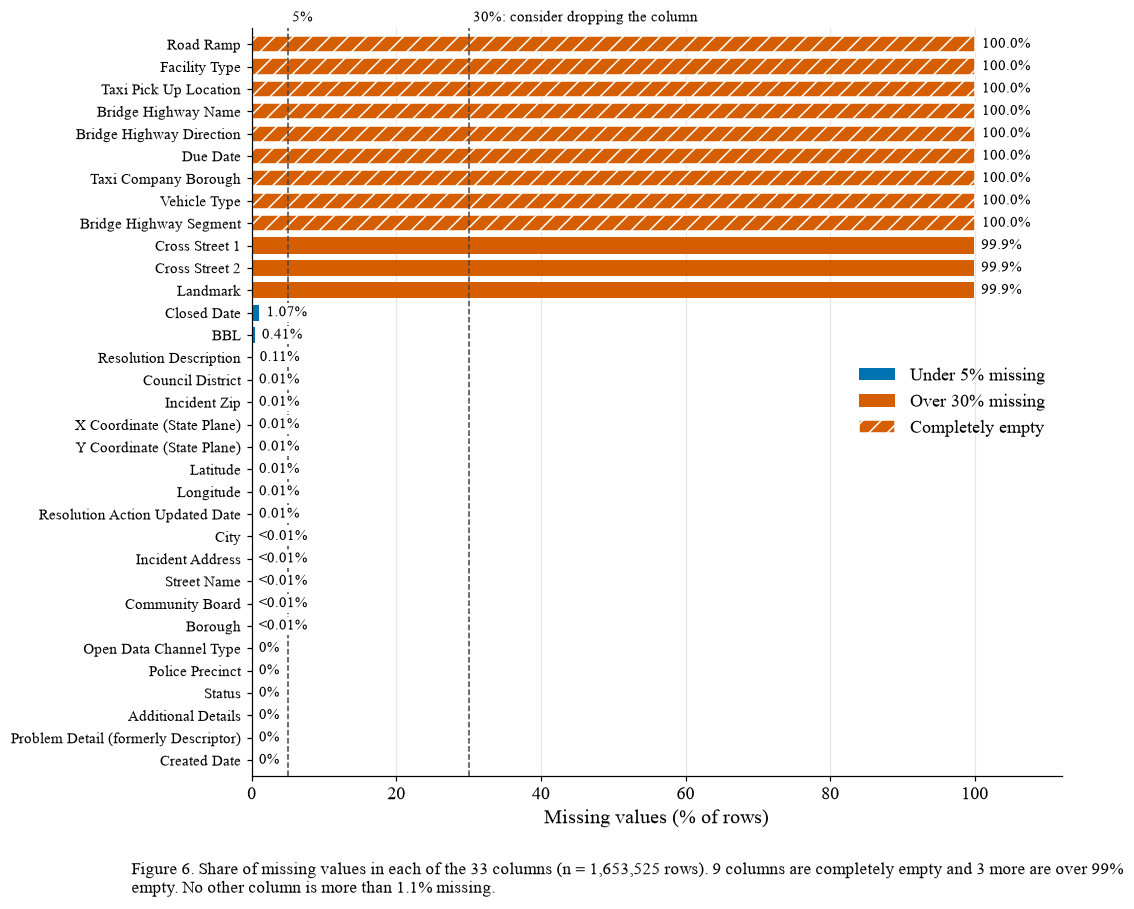

In [47]:
ORANGE = "#E69F00"


def band_colour(percent):
    """Colour by the lecture's three bands: under 5%, 5 to 30%, over 30%."""
    if percent > 30:
        return VERMILION
    if percent >= 5:
        return ORANGE
    return BLUE


names = list(missing_before.index)[::-1]
values = list(missing_before.values)[::-1]

fig, ax = plt.subplots(figsize=(9.5, 8.6))
bars = ax.barh(names, values, color=[band_colour(v) for v in values], height=0.72)

for bar, value in zip(bars, values):
    if value == 100:
        bar.set_hatch("//")
        bar.set_edgecolor("white")
    ax.text(
        value + 1.0,
        bar.get_y() + bar.get_height() / 2,
        percent_label(value),
        va="center",
        fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5},
        zorder=4,
    )

for threshold in (5, 30):
    ax.axvline(threshold, color="#444444", linestyle="--", linewidth=1)
ax.text(5.6, 1.005, "5%", transform=ax.get_xaxis_transform(), fontsize=10, va="bottom")
ax.text(30.6, 1.005, "30%: consider dropping the column", transform=ax.get_xaxis_transform(), fontsize=10, va="bottom")

ax.set_xlim(0, 112)
ax.set_ylim(-0.7, len(names) - 0.3)
fig.subplots_adjust(bottom=0.09)
ax.set_xlabel("Missing values (% of rows)")
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Patch(facecolor=BLUE, label="Under 5% missing"),
        Patch(facecolor=VERMILION, label="Over 30% missing"),
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label="Completely empty"),
    ],
    loc="center right",
)

n_empty = int((missing_before == 100).sum())
n_sparse = int(((missing_before > 99) & (missing_before < 100)).sum())
others_max = missing_before[missing_before < 99].max()
add_caption(
    fig,
    f"Figure 6. Share of missing values in each of the {columns_total} columns (n = {len(clean):,} rows). "
    f"{n_empty} columns are completely empty and {n_sparse} more are over 99% empty. "
    f"No other column is more than {others_max:.1f}% missing.",
    y=0.0,
)
fig.savefig(FIG_DIR / "06_missing_by_column.png")
plt.show()

**Reading Figure 6.** The columns split into two groups with nothing in between.
Twelve columns are essentially empty: nine are 100% blank, and three (`Cross Street 1`, `Cross Street 2`, `Landmark`) are about 99.9% blank.
Every other column is nearly complete, and none of them is anywhere near the 5% line.

### 6.2 Drop the columns that are completely empty

**Decision.** Drop every column whose values are all missing.

**Why.** A column with no values has nothing to learn from, and nothing can be imputed from nothing.
The nine columns are leftovers from other 311 complaint types (vehicles, taxis, bridges and highways) and have no meaning for a heating request.

In [48]:
all_null_cols = [col for col in clean.columns if clean[col].isna().all()]
columns_before = clean.shape[1]

clean = clean.drop(columns=all_null_cols)

print(f"Dropped {len(all_null_cols)} columns that are completely empty:")
for col in all_null_cols:
    print(f"    {col}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 9 columns that are completely empty:
    Facility Type
    Due Date
    Vehicle Type
    Taxi Company Borough
    Taxi Pick Up Location
    Bridge Highway Name
    Bridge Highway Direction
    Road Ramp
    Bridge Highway Segment
clean: 1,653,525 rows x 24 columns (was 33)


**Change made:** 9 completely empty columns dropped (`Facility Type`, `Due Date`, `Vehicle Type`, `Taxi Company Borough`,
`Taxi Pick Up Location`, `Bridge Highway Name`, `Bridge Highway Direction`, `Road Ramp`, `Bridge Highway Segment`).
No rows were removed. The 24 remaining columns all contain at least some data.

### 6.3 Drop the columns that are more than 30% missing

**Rule (Lecture 4).** When more than 30% of a column is missing, the column is too incomplete to trust, and imputing it would mostly be inventing data.
The column is dropped. The code finds these columns from the data instead of using a hand-written list.

In [49]:
DROP_THRESHOLD = 30

missing_now = missing_percent(clean)
over_threshold = missing_now[missing_now > DROP_THRESHOLD]
columns_before = clean.shape[1]

print(f"Columns with more than {DROP_THRESHOLD}% missing: {len(over_threshold)}")
over_threshold.rename("missing (%)").round(3)

Columns with more than 30% missing: 3


Cross Street 1    99.891
Cross Street 2    99.890
Landmark          99.890
Name: missing (%), dtype: float64

In [50]:
dropped_for_missing = list(over_threshold.index)
clean = clean.drop(columns=dropped_for_missing)

print(f"Dropped: {dropped_for_missing}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped: ['Cross Street 1', 'Cross Street 2', 'Landmark']
clean: 1,653,525 rows x 21 columns (was 24)


**Change made: 3 columns dropped for being more than 30% missing.**

| Column | Missing | Note |
|---|---|---|
| `Cross Street 1` | 99.89% | filled in only for requests created 10 Aug to 6 Oct 2023 |
| `Cross Street 2` | 99.89% | same window |
| `Landmark` | 99.89% | same window |

Only about 1,810 of 1.65 million rows have a value in any of them, so they could not describe the typical request.
No rows were removed. `clean` now has 21 columns.

### 6.4 Columns that still have missing values

Nothing is dropped or filled here. This table lists every remaining column with a missing value, with the number of rows affected.

In [51]:
missing_table = pd.DataFrame(
    {
        "type": clean.dtypes.astype(str),
        "missing rows": clean.isna().sum(),
        "missing (%)": (clean.isna().mean() * 100).round(4),
    }
)
missing_table = missing_table[missing_table["missing rows"] > 0].sort_values("missing rows", ascending=False)
missing_table.index.name = "column"

complete = [col for col in clean.columns if col not in missing_table.index]
print(f"{len(missing_table)} of {clean.shape[1]} columns have missing values. Complete columns: {complete}")

missing_table.style.format({"missing rows": "{:,}", "missing (%)": "{:.4f}"})

15 of 21 columns have missing values. Complete columns: ['Created Date', 'Problem Detail (formerly Descriptor)', 'Additional Details', 'Status', 'Police Precinct', 'Open Data Channel Type']


,type,missing rows,missing (%)
column,,,
Closed Date,datetime64[us],"17,654",1.0677
BBL,str,"6,795",0.4109
Resolution Description,str,"1,864",0.1127
Incident Zip,str,190,0.0115
Council District,str,190,0.0115
X Coordinate (State Plane),float64,188,0.0114
Y Coordinate (State Plane),float64,188,0.0114
Latitude,float64,188,0.0114
Longitude,float64,188,0.0114


### 6.5 Drop the open requests (missing target)

**Rule (Lecture 4, slide 29).** For the target variable, drop the rows where it is missing, because a model cannot be trained on answers that do not exist.

Here the target is the time between `Created Date` and `Closed Date`. `Closed Date` is blank exactly when a request has not closed yet,
so these rows have no resolution time. First, a check that the blanks really are the open requests:

In [52]:
open_mask = clean["Closed Date"].isna()
status_of_open = clean.loc[open_mask, "Status"].value_counts()

print(f"Rows with no Closed Date: {int(open_mask.sum()):,} ({open_mask.mean() * 100:.2f}% of rows)")
print()
print("Status of those rows:")
print(status_of_open.to_string())
print()
print(f"Rows with a Closed Date whose Status is Open or In Progress: {int((~open_mask & clean['Status'].isin(['Open', 'In Progress'])).sum())}")

Rows with no Closed Date: 17,654 (1.07% of rows)

Status of those rows:
Status
Open           17481
In Progress      173

Rows with a Closed Date whose Status is Open or In Progress: 0


**Decision.** Drop every request with no `Closed Date`. All of them are `Open` or `In Progress`, and no closed request is missing the date.

Section 7.4 checks the remaining status values as well.

**Why this needs a figure.** The open requests are not a random sample. They are mostly recent, so dropping them removes the requests
that had not had time to close. The figure shows how large that effect is and whether the rest of the data changes shape.

In [53]:
# Summaries of the data before the drop, for the figure.
created_year_before = clean["Created Year"] if "Created Year" in clean.columns else clean["Created Date"].dt.year

open_by_year = pd.DataFrame(
    {
        "all requests": created_year_before.value_counts().sort_index(),
        "open requests": created_year_before[open_mask].value_counts().sort_index(),
    }
).fillna(0)
open_by_year["open (%)"] = open_by_year["open requests"] / open_by_year["all requests"] * 100

borough_before = clean["Borough"].value_counts(normalize=True).reindex(BOROUGHS) * 100
detail_before = clean["Additional Details"].str.upper().value_counts(normalize=True) * 100

rows_before_open_drop = len(clean)
open_by_year.round(2)

,all requests,open requests,open (%)
Created Date,,,
2020,164573,149,0.09
2021,199148,168,0.08
2022,263693,324,0.12
2023,230973,302,0.13
2024,264410,2967,1.12
2025,315479,1532,0.49
2026,215249,12212,5.67


In [54]:
clean = clean[~open_mask].reset_index(drop=True)

borough_after = clean["Borough"].value_counts(normalize=True).reindex(BOROUGHS) * 100
detail_after = clean["Additional Details"].str.upper().value_counts(normalize=True) * 100

n_open_dropped = int(open_mask.sum())
assert clean["Closed Date"].notna().all()
assert rows_before_open_drop - len(clean) == n_open_dropped
print(f"{rows_before_open_drop:,} rows -> {len(clean):,} rows (removed {n_open_dropped:,} open requests)")

1,653,525 rows -> 1,635,871 rows (removed 17,654 open requests)


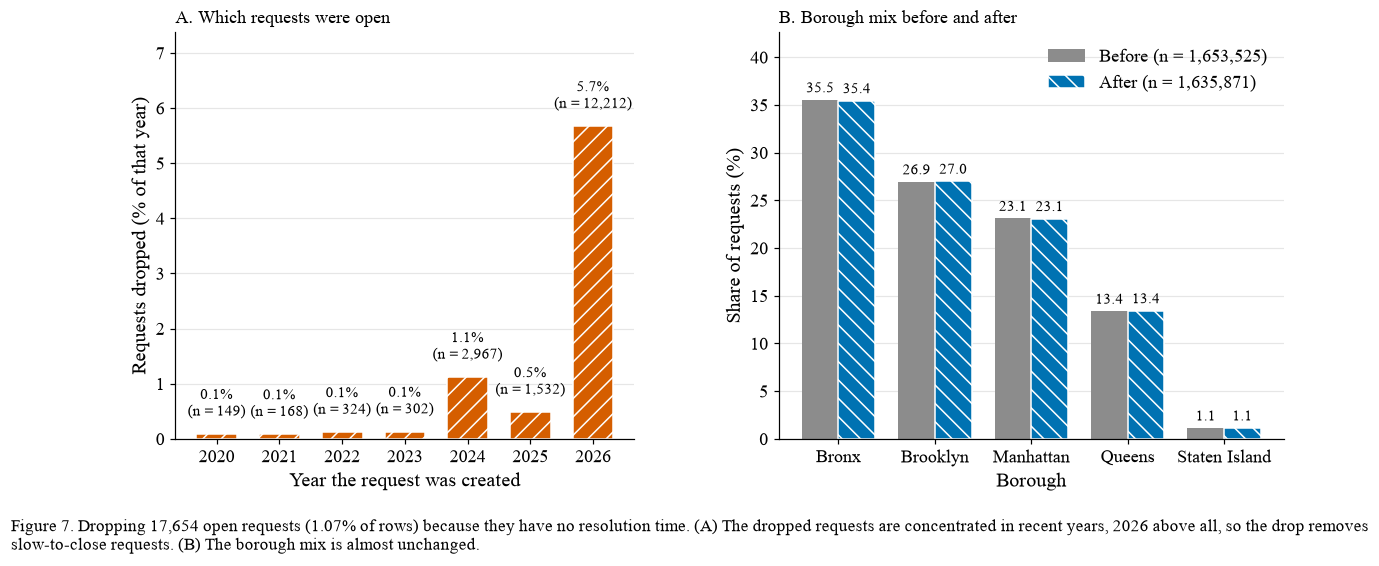

In [55]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.1], "wspace": 0.3})

# Panel A: what share of each year's requests were dropped. Zero baseline.
years = open_by_year.index.to_list()
shares = open_by_year["open (%)"].to_list()
bars = ax_a.bar([str(year) for year in years], shares, color=VERMILION, hatch="//", edgecolor="white", width=0.65)
for bar, share, year in zip(bars, shares, years):
    count = int(open_by_year.loc[year, "open requests"])
    ax_a.text(bar.get_x() + bar.get_width() / 2, share + 0.25, f"{share:.1f}%\n(n = {count:,})", ha="center", va="bottom", fontsize=10)

ax_a.set_ylim(0, max(shares) * 1.3)
ax_a.set_xlabel("Year the request was created")
ax_a.set_ylabel("Requests dropped (% of that year)")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Which requests were open", loc="left", fontsize=12)

# Panel B: borough mix before and after, same zero baseline.
positions = np.arange(len(BOROUGHS))
bar_width = 0.38
ax_b.bar(positions - bar_width / 2, borough_before.values, bar_width, color=GREY)
ax_b.bar(positions + bar_width / 2, borough_after.values, bar_width, color=BLUE, hatch="\\\\", edgecolor="white")
for pos, before_value, after_value in zip(positions, borough_before.values, borough_after.values):
    ax_b.text(pos - bar_width / 2, before_value + 0.8, f"{before_value:.1f}", ha="center", fontsize=10)
    ax_b.text(pos + bar_width / 2, after_value + 0.8, f"{after_value:.1f}", ha="center", fontsize=10)

ax_b.set_xticks(positions)
ax_b.set_xticklabels([name.title() for name in BOROUGHS])
ax_b.set_ylim(0, borough_before.max() * 1.2)
ax_b.set_ylabel("Share of requests (%)")
ax_b.set_xlabel("Borough")
ax_b.grid(axis="x", visible=False)
ax_b.set_title("B. Borough mix before and after", loc="left", fontsize=12)
ax_b.legend(
    handles=[
        Patch(facecolor=GREY, label=f"Before (n = {rows_before_open_drop:,})"),
        Patch(facecolor=BLUE, hatch="\\\\", edgecolor="white", label=f"After (n = {len(clean):,})"),
    ],
    loc="upper right",
)

add_caption(
    fig,
    f"Figure 7. Dropping {n_open_dropped:,} open requests ({n_open_dropped / rows_before_open_drop * 100:.2f}% of rows) because they have no resolution time. "
    f"(A) The dropped requests are concentrated in recent years, 2026 above all, so the drop removes slow-to-close requests. "
    f"(B) The borough mix is almost unchanged.",
)
fig.savefig(FIG_DIR / "07_open_requests_dropped.png")
plt.show()

In [56]:
mix_change = pd.DataFrame({"before (%)": detail_before, "after (%)": detail_after})
mix_change["change (points)"] = mix_change["after (%)"] - mix_change["before (%)"]
mix_change.round(2)

,before (%),after (%),change (points)
Additional Details,,,
NO HEAT,57.86,57.91,0.05
NO HEAT AND NO HOT WATER,25.70,25.71,0.01
NO HOT WATER,16.10,16.03,-0.06
HEAT ON IN SUMMER,0.34,0.35,0.00


**Reading Figure 7.**
- **(A)** Open requests are rare in 2020 to 2023 (about 0.1% each year), then rise to 1.1% in 2024, 0.5% in 2025 and 5.7% in 2026. 2026 holds 12,212 of the 17,654 dropped rows.
  The requests dropped are the ones with the least time to close, so the drop removes slow cases and the target will read slightly faster than reality.
  The year is therefore not a neutral feature, which adds to the case for a time-based train/test split.
- **(B)** The borough mix moves by a fraction of a point, and the table shows the same for the type of problem. Apart from time, the dropped rows look like the rest.

**Change made: 17,654 rows dropped** (all `Open` or `In Progress`). Every remaining request has a `Closed Date`, so the target can be computed for all of them.
`clean` is now 1,635,871 rows by 21 columns. No columns were removed.

## 7. Cleaning step 4: packed and indirect fields

**Question this step answers:** *Does any column hold more than one piece of information, or hold information that only appears once it is computed from other columns?*

The one you expected is the **resolution time**: nothing stores it, but it is the difference between two timestamps.
It is the target, so it is created first.

### 7.1 Create the resolution time (the target)

**Definition.** `Resolution Hours` = `Closed Date` minus `Created Date`, in hours.

Hours fit this data: the median request takes about 43 hours, and 99% finish within a week, so days would be too coarse and minutes too fine.
Every remaining request has both timestamps (the open requests were dropped in 6.5), so every row gets a value.
The new column is only *created* here. Negative values and extreme values are handled in the target-cleaning step.

In [57]:
TARGET = "Resolution Hours"

if TARGET not in clean.columns:
    elapsed = clean["Closed Date"] - clean["Created Date"]
    clean[TARGET] = elapsed.dt.total_seconds() / 3600

target = clean[TARGET]
print(f"{TARGET} created: {target.notna().sum():,} values, {target.isna().sum():,} blank")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

Resolution Hours created: 1,635,871 values, 0 blank
clean: 1,635,871 rows x 22 columns


In [58]:
target.describe().to_frame(TARGET).T

,count,mean,std,min,25%,50%,75%,max
Resolution Hours,1635871.0,50.916073,192.969888,-20.312222,23.654722,42.841389,66.979167,33938.543889


In [59]:
print(f"Negative (closed before created): {(target < 0).sum():,}")
print(f"Zero (closed at the same instant): {(target == 0).sum():,}")
print(f"Over 30 days:                      {(target > 24 * 30).sum():,}")
print(f"Over 1 year:                       {(target > 24 * 365).sum():,}")

Negative (closed before created): 184
Zero (closed at the same instant): 107
Over 30 days:                      443
Over 1 year:                       115


**Change made: 1 column created, `Resolution Hours` (float64, hours).**

The mean (about 51 hours) sits above the median (about 43 hours), and the maximum is about 34,000 hours (nearly four years), so the distribution has a long right tail.
The counts above also show the impossible values waiting for the target-cleaning step: negative values, zeros, and very long durations.
No rows were removed.

### 7.2 Calendar fields packed inside `Created Date`

A timestamp holds several facts at once: the year, the month and the day of the week. A model cannot use them until they are separated,
and the target depends on all three (checked on requests resolved within 30 days):

- **Weekday.** Requests filed on a Friday or Saturday take about 16 hours longer (median about 51 h) than ones filed on a Tuesday (about 35 h).
  This is the clearest pattern, and it is not just winter demand.
- **Month.** It is not a simple winter effect. March to May is fastest (about 32 h) and December and January are slowest (about 48 h).
  A heating-season flag (October to May) separates only 40.2 h from 43.0 h, so the month is used instead of a flag.
- **Year.** Resolution time shifts between years (about 36 h in 2024, about 49 h in 2021).
  So the train/test split should be by time, and year cannot be treated as a clean feature.

Hour of day was left out on purpose; it shows a weaker signal.

Hour of day and a heat-season flag are still created in section 7.10, next to the workload features, so a tree model can combine them.

In [60]:
clean["Created Year"] = clean["Created Date"].dt.year
clean["Created Month"] = clean["Created Date"].dt.month
clean["Created Weekday"] = clean["Created Date"].dt.day_name()

clean[["Created Date", "Created Year", "Created Month", "Created Weekday"]].head()

,Created Date,Created Year,Created Month,Created Weekday
0,2026-10-01 17:53:22,2026,10,Thursday
1,2026-10-01 17:40:17,2026,10,Thursday
2,2026-10-01 17:05:48,2026,10,Thursday
3,2026-10-01 16:40:26,2026,10,Thursday
4,2026-10-01 15:05:30,2026,10,Thursday


In [61]:
check = clean.dropna(subset=[TARGET])
check = check[(check[TARGET] > 0) & (check[TARGET] < 24 * 30)]

by_weekday = check.groupby("Created Weekday")[TARGET].median().reindex(WEEKDAY_ORDER)
by_month = check.groupby("Created Month")[TARGET].median()
by_year = check.groupby("Created Year")[TARGET].median()

pd.DataFrame({"median hours by weekday": by_weekday.round(1)})

,median hours by weekday
Created Weekday,
Monday,40.4
Tuesday,34.9
Wednesday,35.1
Thursday,40.9
Friday,51.3
Saturday,51.3
Sunday,43.7


In [62]:
pd.DataFrame({"median hours by month": by_month.round(1)}).T

Created Month,1,2,3,4,5,6,7,8,9,10,11,12
median hours by month,47.9,43.8,32.2,31.8,31.7,34.4,43.3,42.9,41.0,38.1,45.8,48.4


In [63]:
pd.DataFrame({"median hours by year": by_year.round(1)}).T

Created Year,2020,2021,2022,2023,2024,2025,2026
median hours by year,46.6,49.3,49.0,38.4,36.4,39.4,43.9


**Change made: 3 columns created from `Created Date`.**

| New column | Values | Meaning |
|---|---|---|
| `Created Year` | 2020 to 2026 | year the request was filed |
| `Created Month` | 1 to 12 | month the request was filed |
| `Created Weekday` | Monday to Sunday | day of the week the request was filed |

The tables above confirm the pattern behind each one. The medians are computed only on requests resolved within 30 days, to keep the long tail from hiding the pattern.
No rows were removed.

### 7.3 One spelling per category in `Problem Detail` and `Additional Details`

**The problem.** Both columns spell each category two ways, for example `ENTIRE BUILDING` and `Entire Building`.
HPD switched to Title case only for requests created between 10 Aug and 6 Oct 2023, so a raw count splits one category in two,
and a model would treat the two spellings as different values. `Problem Detail` also holds one row reading `Water Supply`,
which is not a heating scope.

In [64]:
# Upper-case and trim both columns so each category has a single spelling.
DETAIL_COL = "Problem Detail (formerly Descriptor)"
EXTRA_COL = "Additional Details"
VALID_SCOPES = ["ENTIRE BUILDING", "APARTMENT ONLY"]

for col in [DETAIL_COL, EXTRA_COL]:
    canonical = clean[col].str.strip().str.upper()
    respelled = clean[col].notna() & (clean[col] != canonical)
    first = clean.loc[respelled, "Created Date"].min()
    last = clean.loc[respelled, "Created Date"].max()
    distinct_before = clean[col].nunique()
    clean[col] = canonical
    print(f"{col}: {distinct_before} spellings -> {clean[col].nunique()} categories; "
          f"{int(respelled.sum()):,} rows re-spelled, all created {first:%d %b %Y} to {last:%d %b %Y}")

Problem Detail (formerly Descriptor): 5 spellings -> 3 categories; 1,641 rows re-spelled, all created 10 Aug 2023 to 06 Oct 2023
Additional Details: 8 spellings -> 4 categories; 1,641 rows re-spelled, all created 10 Aug 2023 to 06 Oct 2023


In [65]:
# 'Water Supply' is not a heating scope, so it becomes a blank. The row itself stays.
not_a_scope = clean[DETAIL_COL].notna() & ~clean[DETAIL_COL].isin(VALID_SCOPES)
print(clean.loc[not_a_scope, DETAIL_COL].value_counts().to_string())
clean.loc[not_a_scope, DETAIL_COL] = np.nan

pd.concat(
    [clean[DETAIL_COL].value_counts(dropna=False), clean[EXTRA_COL].value_counts(dropna=False)],
    keys=[DETAIL_COL, EXTRA_COL],
).rename("rows").to_frame()

Problem Detail (formerly Descriptor)
WATER SUPPLY    1


rows
Problem Detail (formerly Descriptor) ENTIRE BUILDING           1069105
                                     APARTMENT ONLY             566765
                                     nan                             1
Additional Details                   NO HEAT                    947267
                                     NO HEAT AND NO HOT WATER   420654
                                     NO HOT WATER               262285
                                     HEAT ON IN SUMMER            5665

**Decision.** Keep the upper-case spelling in both columns. `Problem Detail` now has 2 categories and `Additional Details` 4.
The single `Water Supply` value is blanked rather than dropped, because the request itself is a valid heating request.
No rows or columns were removed.

### 7.4 `Status` must agree with `Closed Date`

Section 6.5 dropped the rows with no `Closed Date` and checked that no `Open` or `In Progress` row had a closing date.
It did not check the other status values. A request is treated as closed only when **both** fields say so.

In [66]:
# Closed means Status == 'Closed' AND a Closed Date exists.
is_closed = (clean["Status"] == "Closed") & clean["Closed Date"].notna()
print(f"Rows that are not confirmed closed: {int((~is_closed).sum())}")
clean.loc[~is_closed, ["Created Date", "Closed Date", "Status", TARGET]]

Rows that are not confirmed closed: 2


,Created Date,Closed Date,Status,Resolution Hours
883213,2023-10-02 14:55:22,2023-10-03,Unspecified,9.077222
885211,2023-09-29 14:42:17,2023-10-04,Unspecified,105.295278


In [67]:
# Drop the unconfirmed rows; Status is then one value in every row, so it goes too.
rows_before_status_drop = len(clean)
clean = clean[is_closed].reset_index(drop=True)
n_status_dropped = rows_before_status_drop - len(clean)

assert (clean["Status"] == "Closed").all()
clean = clean.drop(columns=["Status"])
print(f"{rows_before_status_drop:,} rows -> {len(clean):,} rows (removed {n_status_dropped} rows whose Status is not 'Closed')")
print(f"Rows removed for a missing or unconfirmed target, 6.5 plus 7.4: {n_open_dropped + n_status_dropped:,}")

1,635,871 rows -> 1,635,869 rows (removed 2 rows whose Status is not 'Closed')
Rows removed for a missing or unconfirmed target, 6.5 plus 7.4: 17,656


**Decision.** Drop the 2 rows whose `Status` is `Unspecified` even though they carry a `Closed Date`.
Nothing confirms they were really closed, so their resolution time cannot be trusted. Together with section 6.5 that makes
17,656 rows removed for a missing or unconfirmed target. `Status` is then `Closed` in every row, so it is dropped as a constant column
(it was also only known after resolution).

### 7.5 Negative and zero resolution times

A negative `Resolution Hours` means the request closed before it was opened. That is Lecture 4's third disguise of missing data:
a legal-looking value that is impossible. A zero means it closed in the same second it was created.

In [68]:
# Flag both cases; blank the negative values so they never enter the target.
negative = clean[TARGET] < 0
clean["Is Negative Duration"] = negative
clean["Is Instant Close"] = clean[TARGET] == 0

print(f"Negative: {int(negative.sum())} rows")
print(f"    within one minute of zero (clock noise): {int((negative & (clean[TARGET] >= -1 / 60)).sum())}")
print(f"    range: {clean.loc[negative, TARGET].min():,.1f} h to {clean.loc[negative, TARGET].max():,.2f} h")
print(f"Zero:     {int(clean['Is Instant Close'].sum())} rows ({clean['Is Instant Close'].mean() * 100:.3f}%)")

clean.loc[negative, TARGET] = np.nan
n_modelling = int(clean[TARGET].notna().sum())
print(f"Rows with a usable target: {n_modelling:,}")

Negative: 184 rows
    within one minute of zero (clock noise): 0
    range: -20.3 h to -0.05 h
Zero:     107 rows (0.007%)
Rows with a usable target: 1,635,685


**Decision.**
- **184 negative values**: set `Resolution Hours` to blank and keep a flag (`Is Negative Duration`). None is within a minute of zero,
  so they are not clock noise that could be rounded to 0. The row stays in the data for counting, but it is excluded from the target and from modelling.
- **107 zero values**: kept, with a flag (`Is Instant Close`). They are 0.007% of rows, too few to move any statistic, and nothing shows they are errors.

The modelling set is now **1,635,685 rows** (1,635,869 rows minus the 184 blank targets).

### 7.6 The long right tail of `Resolution Hours`

**Question this step answers:** *How long is the tail, and should it be removed, capped or transformed?*

In [69]:
# Describe the tail before deciding anything.
valid = clean[TARGET].dropna()
q1, q3 = valid.quantile([0.25, 0.75])
iqr_fence = q3 + 1.5 * (q3 - q1)
P995 = valid.quantile(0.995)

tail_summary = pd.Series(
    {
        "median (h)": valid.median(),
        "mean (h)": valid.mean(),
        "90th pct (h)": valid.quantile(0.9),
        "99th pct (h)": valid.quantile(0.99),
        "99.5th pct (h)": P995,
        "max (h)": valid.max(),
        "IQR upper fence (h)": iqr_fence,
        "rows above the fence": (valid > iqr_fence).sum(),
        "rows over 72 h (%)": (valid > 72).mean() * 100,
        "rows over 30 days": (valid > 24 * 30).sum(),
        "rows over 1 year": (valid > 24 * 365).sum(),
        "skew, raw": valid.skew(),
        "skew, log1p": np.log1p(valid).skew(),
        "skew, capped at 99.5th pct": valid.clip(upper=P995).skew(),
    }
)
tail_summary.round(2).to_frame("value")

,value
median (h),42.85
mean (h),50.92
90th pct (h),95.04
99th pct (h),159.67
99.5th pct (h),176.77
max (h),33938.54
IQR upper fence (h),131.97
rows above the fence,45619.00
rows over 72 h (%),21.13
rows over 30 days,443.00


In [70]:
# Two modelling-ready versions of the target; the raw column is kept unchanged.
clean["Slow Over 72h"] = (clean[TARGET] > 72).astype("boolean")
clean.loc[clean[TARGET].isna(), "Slow Over 72h"] = pd.NA  # no target, no label
clean["Resolution Hours Capped"] = clean[TARGET].clip(upper=P995)
print(f"Cap at the 99.5th percentile: {P995:.1f} h; {(valid > P995).sum():,} values capped")

Cap at the 99.5th percentile: 176.8 h; 8,179 values capped


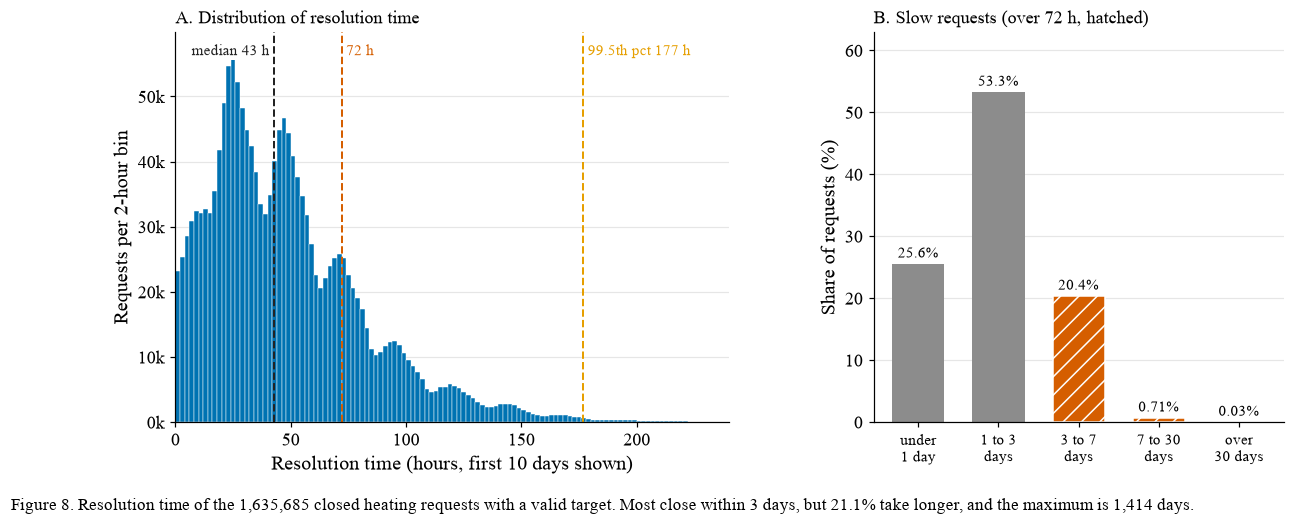

In [71]:
# Figure 8.
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.35, 1], "wspace": 0.3})

# Panel A: the body of the distribution, in 2-hour bins, up to 10 days.
ax_a.hist(valid[valid <= 240], bins=np.arange(0, 242, 2), color=BLUE, edgecolor="white", linewidth=0.3)
for x, label, colour, side in [(valid.median(), f"median {valid.median():.0f} h", "#222222", "right"),
                               (72, "72 h", VERMILION, "left"),
                               (P995, f"99.5th pct {P995:.0f} h", ORANGE, "left")]:
    ax_a.axvline(x, color=colour, linestyle="--", linewidth=1.3)
    offset = -2 if side == "right" else 2
    ax_a.text(x + offset, 0.97, label, transform=ax_a.get_xaxis_transform(), fontsize=10, va="top", ha=side, color=colour,
              bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
ax_a.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax_a.set_xlim(0, 240)
ax_a.set_xlabel("Resolution time (hours, first 10 days shown)")
ax_a.set_ylabel("Requests per 2-hour bin")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Distribution of resolution time", loc="left", fontsize=12)

# Panel B: share of requests in each duration band.
bands = pd.cut(valid, bins=[-0.001, 24, 72, 168, 720, np.inf],
               labels=["under\n1 day", "1 to 3\ndays", "3 to 7\ndays", "7 to 30\ndays", "over\n30 days"])
band_share = bands.value_counts(normalize=True, sort=False) * 100
band_colours = [GREY, GREY, VERMILION, VERMILION, VERMILION]
bars = ax_b.bar(band_share.index.astype(str), band_share.values, color=band_colours, width=0.65)
for bar, colour in zip(bars, band_colours):
    if colour == VERMILION:
        bar.set_hatch("//")
        bar.set_edgecolor("white")
for bar, value in zip(bars, band_share.values):
    ax_b.text(bar.get_x() + bar.get_width() / 2, value + 1, percent_label(value), ha="center", fontsize=10)
ax_b.set_ylim(0, band_share.max() * 1.18)
ax_b.set_ylabel("Share of requests (%)")
ax_b.tick_params(axis="x", labelsize=10)
ax_b.grid(axis="x", visible=False)
ax_b.set_title("B. Slow requests (over 72 h, hatched)", loc="left", fontsize=12)

add_caption(
    fig,
    f"Figure 8. Resolution time of the {len(valid):,} closed heating requests with a valid target. "
    f"Most close within 3 days, but {band_share.iloc[2:].sum():.1f}% take longer, and the maximum is {valid.max() / 24:,.0f} days.",
)
fig.savefig(FIG_DIR / "08_resolution_time_tail.png")
plt.show()

**Decision on the tail.**
- **Keep every long value.** Nothing marks them as entry errors, and slow cases are exactly what the project wants to predict.
- **Report medians**, not means: the mean sits about 8 hours above the median, pulled by a few hundred rows.
- Two modelling-ready versions are stored next to the raw target: `Slow Over 72h` (classification) and `Resolution Hours Capped`
  (regression, capped at the 99.5th percentile). Whether the regression target should also be log-transformed is tested next.

### 7.6.1 Should the target be log-transformed for a model?

**Question this step answers:** *Does `log1p(Resolution Hours)` give a model an easier target than raw hours?*

A log transform helps a regression model for three separate reasons, and each can be checked in the data:

| Reason | What to look for | Check |
|---|---|---|
| Skew | a long right tail that dominates a squared-error loss | skew before and after (table below) |
| Spread grows with the level | slow groups also vary more, so errors are multiplicative | spread against level by group (Figure 10) |
| Shape | the transformed target looks closer to a bell curve | QQ plots (Figure 9) |

`log1p` (log of 1 + hours) is used instead of `log` so that the 107 zero-hour requests stay finite.

In [72]:
capped = valid.clip(upper=P995)
versions = {
    "raw hours": valid,
    "capped at 99.5th pct": capped,
    "square root": np.sqrt(valid),
    "log1p": np.log1p(valid),
    "log1p of capped": np.log1p(capped),
}

shape_rows = []
for name, series in versions.items():
    shape_rows.append({"target version": name, "skew": series.skew(), "excess kurtosis": series.kurt()})
shape_table = pd.DataFrame(shape_rows).set_index("target version")

print(f"Requests closed in under 1 hour:  {(valid < 1).mean() * 100:.2f}%")
print(f"Requests closed in under 6 hours: {(valid < 6).mean() * 100:.2f}%")
shape_table.round(2)

Requests closed in under 1 hour:  0.69%
Requests closed in under 6 hours: 4.71%


,skew,excess kurtosis
target version,,
raw hours,119.01,16346.82
capped at 99.5th pct,1.13,1.36
square root,9.98,476.95
log1p,-0.95,1.83
log1p of capped,-1.03,1.55


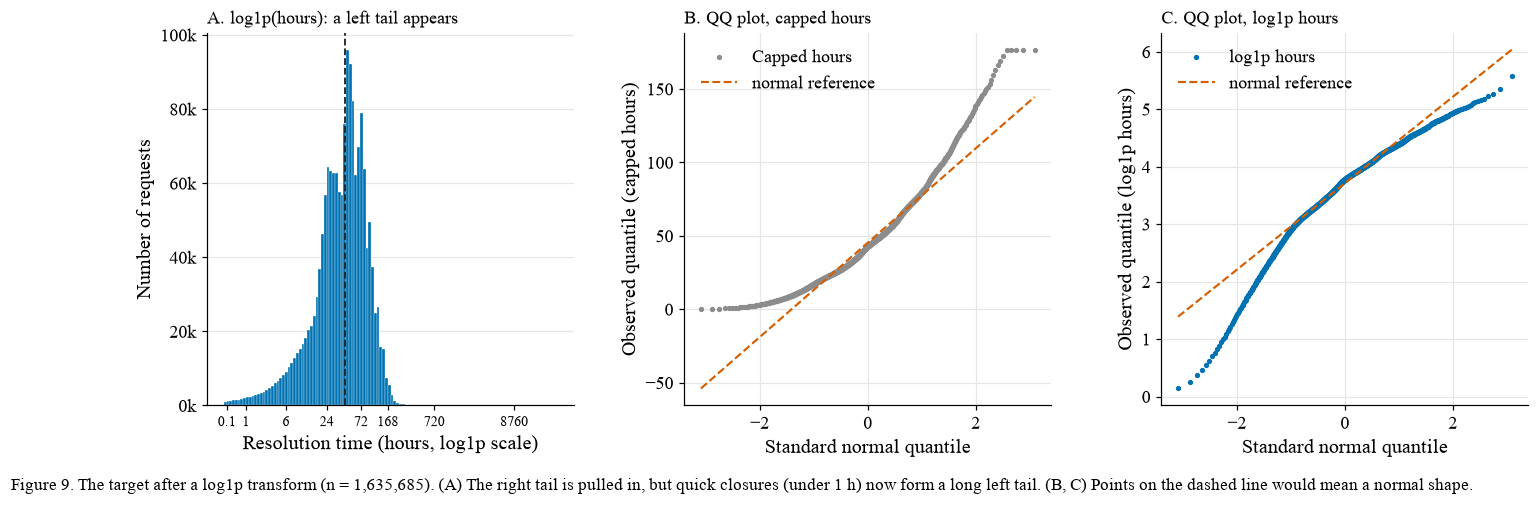

In [73]:
def qq_points(series, n_points=999):
    """Observed quantiles against standard-normal quantiles, plus the line through the quartiles."""
    probabilities = np.linspace(0.001, 0.999, n_points)
    normal = NormalDist()
    theoretical = np.array([normal.inv_cdf(p) for p in probabilities])
    observed = np.quantile(series, probabilities)
    q1_obs, q3_obs = np.quantile(series, [0.25, 0.75])
    q1_th = normal.inv_cdf(0.25)
    q3_th = normal.inv_cdf(0.75)
    slope = (q3_obs - q1_obs) / (q3_th - q1_th)
    intercept = q1_obs - slope * q1_th
    return theoretical, observed, slope * theoretical + intercept


log_valid = np.log1p(valid)
HOUR_TICKS = [0.1, 1, 6, 24, 72, 168, 720, 8760]

fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(15.5, 4.4), gridspec_kw={"wspace": 0.3})

# Panel A: the target on the log1p scale, with tick labels in hours.
ax_a.hist(log_valid, bins=120, color=BLUE, edgecolor="white", linewidth=0.2)
ax_a.set_xticks(np.log1p(HOUR_TICKS))
ax_a.set_xticklabels(["0.1", "1", "6", "24", "72", "168", "720", "8760"], fontsize=9)
ax_a.axvline(np.log1p(valid.median()), color="#222222", linestyle="--", linewidth=1.2)
ax_a.set_xlabel("Resolution time (hours, log1p scale)")
ax_a.set_ylabel("Number of requests")
ax_a.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. log1p(hours): a left tail appears", loc="left", fontsize=12)

# Panels B and C: QQ plots of the capped target and of log1p.
for ax, series, label, colour, title in [
    (ax_b, capped, "Capped hours", GREY, "B. QQ plot, capped hours"),
    (ax_c, log_valid, "log1p hours", BLUE, "C. QQ plot, log1p hours"),
]:
    theoretical, observed, reference = qq_points(series)
    ax.scatter(theoretical, observed, s=6, color=colour, label=label)
    ax.plot(theoretical, reference, color=VERMILION, linestyle="--", linewidth=1.4, label="normal reference")
    ax.set_xlabel("Standard normal quantile")
    ax.set_ylabel(f"Observed quantile ({label.lower()})")
    ax.set_title(title, loc="left", fontsize=12)
    ax.legend(loc="upper left")

add_caption(
    fig,
    f"Figure 9. The target after a log1p transform (n = {len(valid):,}). (A) The right tail is pulled in, but quick closures "
    f"(under 1 h) now form a long left tail. (B, C) Points on the dashed line would mean a normal shape.",
)
fig.savefig(FIG_DIR / "09_log_transform_shape.png")
plt.show()

**Does the spread grow with the level?** Each point below is one borough in one month. If slow groups are also the most variable on the raw scale,
but the spread is flat on the log scale, the noise is multiplicative and a log target matches it.

In [74]:
groups = clean.dropna(subset=[TARGET]).copy()
groups["month"] = groups["Created Date"].dt.to_period("M")
groups["log1p hours"] = np.log1p(groups[TARGET])
grouped = groups.groupby(["Borough", "month"])

spread = pd.DataFrame(
    {
        "rows": grouped.size(),
        "median (h)": grouped[TARGET].median(),
        "IQR (h)": grouped[TARGET].quantile(0.75) - grouped[TARGET].quantile(0.25),
        "median (log)": grouped["log1p hours"].median(),
        "IQR (log)": grouped["log1p hours"].quantile(0.75) - grouped["log1p hours"].quantile(0.25),
    }
)
MIN_GROUP_ROWS = 300
spread = spread[spread["rows"] >= MIN_GROUP_ROWS]

rho_raw = spread["median (h)"].rank().corr(spread["IQR (h)"].rank())
rho_log = spread["median (log)"].rank().corr(spread["IQR (log)"].rank())
print(f"{len(spread)} borough-months with at least {MIN_GROUP_ROWS} requests")
print(f"Spearman(level, spread), raw hours:  {rho_raw:+.2f}")
print(f"Spearman(level, spread), log1p hours: {rho_log:+.2f}")

342 borough-months with at least 300 requests
Spearman(level, spread), raw hours:  +0.89
Spearman(level, spread), log1p hours: +0.04


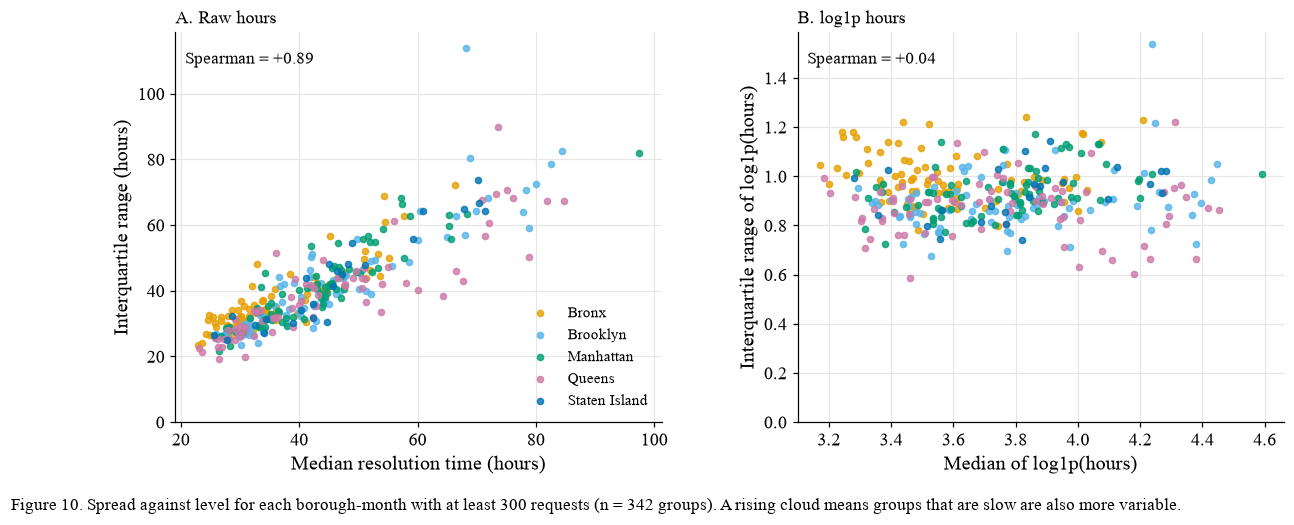

In [75]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"wspace": 0.28})

for ax, x_col, y_col, rho, xlabel, ylabel, title in [
    (ax_a, "median (h)", "IQR (h)", rho_raw, "Median resolution time (hours)", "Interquartile range (hours)", "A. Raw hours"),
    (ax_b, "median (log)", "IQR (log)", rho_log, "Median of log1p(hours)", "Interquartile range of log1p(hours)", "B. log1p hours"),
]:
    for borough in BOROUGHS:
        part = spread.loc[borough] if borough in spread.index.get_level_values(0) else None
        if part is None:
            continue
        ax.scatter(part[x_col], part[y_col], s=16, color=BOROUGH_COLOURS[borough], alpha=0.8, label=borough.title())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)
    ax.set_title(title, loc="left", fontsize=12)
    ax.text(0.02, 0.95, f"Spearman = {rho:+.2f}", transform=ax.transAxes, va="top", fontsize=11)

ax_a.legend(loc="lower right", fontsize=10)
add_caption(
    fig,
    f"Figure 10. Spread against level for each borough-month with at least {MIN_GROUP_ROWS} requests (n = {len(spread)} groups). "
    f"A rising cloud means groups that are slow are also more variable.",
)
fig.savefig(FIG_DIR / "10_log_transform_spread.png")
plt.show()

**Reading Figures 9 and 10, and the model check.**

- **Skew alone is the wrong test.** `log1p` turns a skew of +119 into −0.95, which looked like over-correction in the first version of this notebook.
  The new left tail is real but small: 0.7% of requests close in under 1 hour and 4.7% in under 6 hours (Figure 9A, 9C).
  Capping at the 99.5th percentile gives a lower skew (1.1), but its QQ plot (9B) still bends upward across the whole right half.
- **The noise is multiplicative.** On raw hours, a borough-month that is slow is also far more spread out (Spearman +0.89, Figure 10A).
  On the log scale the spread is flat (+0.04, Figure 10B). A squared-error model on raw hours would therefore spend its effort on the
  slow, noisy months; on the log scale every request weighs about the same.
- **The model test agrees** (`target_transform_check.py`, train 2020 to 2024, test January 2025 to September 2026, same features and settings):

| Gradient-boosted trees trained on | MAE (h) | median abs. error (h) | RMSE (h) | mean bias (h) |
|---|---|---|---|---|
| raw hours | 28.2 | 21.0 | 69.3 | +13.1 |
| hours capped at 99.5th pct | 25.5 | 20.9 | 50.5 | +11.1 |
| raw hours, absolute-error loss | 24.7 | 19.6 | 50.1 | +8.9 |
| **log1p hours, back-transformed with expm1** | **22.1** | **17.4** | **48.5** | **−1.4** |
| (baseline: training median for everyone) | 23.5 | 19.8 | 49.5 | −1.8 |

**Decision.** Train the regression on `log1p(Resolution Hours)` and convert predictions back with `expm1`. It is the best target on every
average-error metric and the least biased, for both trees and ridge regression. The prediction is then a *typical* (median-like) time,
which is what a tenant should be told. Its weakness is the slow tail: on requests that took over 72 hours it errs by about 44 h, against
33 h for the capped target, which is why `Slow Over 72h` stays as a companion classification target. A smearing correction, which rescales
toward the mean, made MAE worse (25.8 h) and is not used. All models beat the median baseline only modestly, so the feature work
(weather, workload known at filing time) matters more than the choice of algorithm.

### 7.7 Text and numbers standing in for a missing value

Lecture 4's second disguise: a value that `isna()` cannot see. The rules below were found by searching every column for `Unspecified`
and checking codes against their valid ranges.

In [76]:
# Each rule marks the values that only pretend to be data.
NYC_ZIP = r"1(0[0-4]|1[0-6])\d\d"
outside_nyc = clean["Latitude"].notna() & ~(clean["Latitude"].between(40.45, 40.95) & clean["Longitude"].between(-74.3, -73.65))

placeholder_rules = {
    "Borough": clean["Borough"] == "Unspecified",
    "Police Precinct": clean["Police Precinct"] == "Unspecified",
    "Community Board": clean["Community Board"].str.contains("Unspecified", na=False),
    "Incident Zip": clean["Incident Zip"].notna() & ~clean["Incident Zip"].str.fullmatch(NYC_ZIP, na=False),
    "BBL": clean["BBL"] == "0000000000",
}

for col, mask in placeholder_rules.items():
    examples = clean.loc[mask, col].value_counts().head(4).to_dict()
    print(f"{col:16s} {int(mask.sum()):>5,} rows   e.g. {examples}")
    clean.loc[mask, col] = np.nan

print(f"{'Latitude/Longitude':16s} {int(outside_nyc.sum()):>5,} rows outside the NYC bounding box")
clean.loc[outside_nyc, ["Latitude", "Longitude", "X Coordinate (State Plane)", "Y Coordinate (State Plane)"]] = np.nan

Borough              4 rows   e.g. {'Unspecified': 4}
Police Precinct  2,103 rows   e.g. {'Unspecified': 2103}
Community Board    639 rows   e.g. {'Unspecified BRONX': 238, 'Unspecified QUEENS': 176, 'Unspecified BROOKLYN': 147, 'Unspecified MANHATTAN': 74}
Incident Zip         4 rows   e.g. {'12345': 3, '10803': 1}
BBL                323 rows   e.g. {'0000000000': 323}
Latitude/Longitude     0 rows outside the NYC bounding box


**Decision.** Replace each placeholder with a real blank, so it is counted as missing and never read as a category of its own.
- `Borough` `Unspecified`, `Police Precinct` `Unspecified`, and `Community Board` values such as `Unspecified BRONX` or `0 Unspecified` become blank.
- `Incident Zip` values outside NYC's ranges (`12345`, and `10803` in Westchester) become blank.
- `BBL` `0000000000` is not a real tax lot and becomes blank.
- The coordinate check finds no point outside NYC in this data; it stays in the notebook so a future extract is checked the same way.

No rows were removed. These columns stay well under the 5% line, so the blanks are left as blanks (no imputation).

### 7.8 One ID per building

`BBL` (borough, block and lot) identifies the building, but it is blank in about 0.4% of rows.
Building history is one of the strongest signals in this data (section 7.10), so a missing `BBL` should not erase a building's history.

In [77]:
# BBL where it exists, otherwise the normalised address plus zip code.
def building_id(frame):
    address = frame["Incident Address"].str.upper().str.replace(r"\s+", " ", regex=True).str.strip()
    zip_code = frame["Incident Zip"].where(frame["Incident Zip"].str.fullmatch(NYC_ZIP, na=False), "")
    bbl = frame["BBL"].where(frame["BBL"] != "0000000000")
    return bbl.fillna(address + "|" + zip_code)


clean["Building ID"] = building_id(clean)

per_building = clean["Building ID"].value_counts()
top_1 = per_building.head(int(len(per_building) * 0.01)).sum() / per_building.sum() * 100
top_10 = per_building.head(int(len(per_building) * 0.10)).sum() / per_building.sum() * 100
print(f"BBL blank: {clean['BBL'].isna().sum():,} rows; Building ID blank after the fallback: {clean['Building ID'].isna().sum():,}")
print(f"{len(per_building):,} buildings. The busiest 1% file {top_1:.0f}% of requests, the busiest 10% file {top_10:.0f}%.")

BBL blank: 7,060 rows; Building ID blank after the fallback: 3
95,119 buildings. The busiest 1% file 32% of requests, the busiest 10% file 74%.


**Decision.** Create `Building ID` = `BBL`, or the address and zip code where `BBL` is blank. `BBL` itself is kept unchanged.
Complaints are highly concentrated: a small share of buildings files most of the requests.

### 7.9 `Resolution Description` as an outcome category (EDA only)

`Resolution Description` is one of 43 fixed sentences HPD writes when it closes a request. Grouping them shows *how* requests end.
It is written at closing time, so it is **leakage**: it may be used to explain the data, never as a model feature.

In [78]:
# Map the template sentences to a short outcome label.
OUTCOME_RULES = [  # first match wins
    ("Duplicate of open building-wide complaint", r"duplicate"),
    ("Still open / owner notified", r"still open"),
    ("No access", r"not able to gain access|unable to complete|was not able to gain"),
    ("Violation issued", r"violations were issued|violation was issued|violations were previously issued"),
    ("Heat not required (temp above 55F)", r"not required"),
    ("Restored per tenant/phone", r"restored|verified that the following conditions were corrected|indicated that the condition was corrected|verified that the complaint was addressed"),
    ("Inspected, no violation", r"no violations were issued|did not violate"),
    ("Inspection result on HPDONLINE", r"conducted or attempted to conduct"),
    ("Administrative close", r"administratively"),
]

text = clean["Resolution Description"].fillna("").str.lower()
clean["Outcome (EDA only)"] = np.where(text == "", "Missing", "Other")
for label, pattern in reversed(OUTCOME_RULES):
    clean.loc[text.str.contains(pattern, regex=True), "Outcome (EDA only)"] = label

outcome_table = clean.groupby("Outcome (EDA only)")[TARGET].agg(rows="size", median_hours="median")
outcome_table["share (%)"] = outcome_table["rows"] / len(clean) * 100
outcome_table.sort_values("rows", ascending=False).round(1)

,rows,median_hours,share (%)
Outcome (EDA only),,,
Restored per tenant/phone,583609,42.1,35.7
Duplicate of open building-wide complaint,462554,43.7,28.3
No access,249743,52.7,15.3
Violation issued,157317,51.7,9.6
Inspection result on HPDONLINE,136814,7.7,8.4
"Inspected, no violation",38979,54.9,2.4
Still open / owner notified,4187,74.9,0.3
Missing,1639,28.4,0.1
Administrative close,1026,3.4,0.1


**Decision.** Keep `Outcome (EDA only)` for describing the data and for Tableau views, and exclude it from every model,
together with `Resolution Description` and `Resolution Action Updated Date`.

### 7.10 Workload, building history and time-of-day features

These are known the moment a request is filed, so a model may use them. Counts use **every** heating request except the exact duplicates,
including the open ones dropped in 6.5, because an open complaint still adds to that day's workload and to the building's record.

In [79]:
# The history every count is taken from.
history = heating.loc[~is_duplicate, ["Created Date", "Incident Address", "Incident Zip", "BBL"]].copy()
history["Created Date"] = pd.to_datetime(history["Created Date"], format=DATE_FORMAT)
history["Building ID"] = building_id(history)
history["day"] = history["Created Date"].dt.normalize()
print(f"History: {len(history):,} requests")

clean_day = clean["Created Date"].dt.normalize()

# Calendar.
clean["Created Hour"] = clean["Created Date"].dt.hour
clean["Heat Season"] = ~clean["Created Month"].isin([6, 7, 8, 9])  # NYC heat season is 1 Oct to 31 May
season_start = np.where(clean["Created Month"] >= 10, clean["Created Year"], clean["Created Year"] - 1)
clean["Season"] = np.where(
    clean["Heat Season"],
    pd.Series(season_start).astype(str) + "-" + pd.Series((season_start + 1) % 100).astype(str).str.zfill(2),
    "off-season",
)

# City workload. Heating requests filed citywide on the same day.
daily_volume = history.groupby("day").size()
clean["City Daily Volume"] = clean_day.map(daily_volume).to_numpy()

# Requests from the same building on the same day (a building-wide outage).
same_day = history.groupby(["Building ID", "day"]).size()
clean["Building Same Day"] = same_day.reindex(pd.MultiIndex.from_arrays([clean["Building ID"], clean_day])).to_numpy()

# Requests from the same building in the 365 days before this one.
# Sort (building, time) as one integer key, then count with two binary searches.
known = history["Building ID"].notna()
codes, uniques = pd.factorize(history.loc[known, "Building ID"])
start = pd.Timestamp("2020-01-01")
seconds = lambda s: ((s - start).dt.total_seconds()).astype("int64").to_numpy()
sorted_keys = np.sort(codes.astype("int64") * 10**10 + seconds(history.loc[known, "Created Date"]))

clean_codes = pd.Index(uniques).get_indexer(clean["Building ID"])
query = clean_codes.astype("int64") * 10**10 + seconds(clean["Created Date"])
prior = np.searchsorted(sorted_keys, query, side="left") - np.searchsorted(sorted_keys, query - 365 * 86400, side="left")
clean["Building Prior 365d"] = np.where(clean_codes >= 0, prior, np.nan)

new_features = ["Created Hour", "Heat Season", "Season", "City Daily Volume", "Building Same Day", "Building Prior 365d"]
clean[new_features].describe(include="all").T

History: 1,653,525 requests


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Created Hour,1635869.0,NaN,NaN,NaN,12.915306,6.073579,0.0,9.0,13.0,18.0,23.0
Heat Season,1635869,2,True,1546779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,1635869,9,2025-26,330209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City Daily Volume,1635869.0,NaN,NaN,NaN,1554.610732,1152.061185,34.0,780.0,1288.0,2041.0,6112.0
Building Same Day,1635866.0,NaN,NaN,NaN,3.272182,5.976222,1.0,1.0,1.0,3.0,124.0
Building Prior 365d,1635866.0,NaN,NaN,NaN,113.710858,378.81864,0.0,5.0,19.0,64.0,4178.0


In [80]:
# Does each new feature move the median resolution time?
with_target = clean.dropna(subset=[TARGET])

volume_band = pd.cut(with_target["City Daily Volume"], [0, 500, 1000, 2000, 4000, np.inf],
                     labels=["under 500", "500-1k", "1k-2k", "2k-4k", "over 4k"])
history_band = pd.cut(with_target["Building Prior 365d"], [-1, 0, 4, 19, 99, np.inf],
                      labels=["0", "1-4", "5-19", "20-99", "100+"])

by_volume = with_target.groupby(volume_band, observed=True)[TARGET].agg(rows="size", median_hours="median")
by_history = with_target.groupby(history_band, observed=True)[TARGET].agg(rows="size", median_hours="median")
by_season = with_target.groupby("Heat Season")[TARGET].agg(rows="size", median_hours="median")
pd.concat([by_volume, by_history, by_season], keys=["city daily volume", "building prior 365 days", "heat season"]).round(1)

rows  median_hours
city daily volume       under 500   214376          34.1
                        500-1k      388211          35.9
                        1k-2k       597768          43.4
                        2k-4k       355769          49.9
                        over 4k      79561          66.7
building prior 365 days 0           137241          51.9
                        1-4         270413          49.3
                        5-19        427801          45.8
                        20-99       507204          39.7
                        100+        293023          31.7
heat season             False        89068          40.3
                        True       1546617          43.0

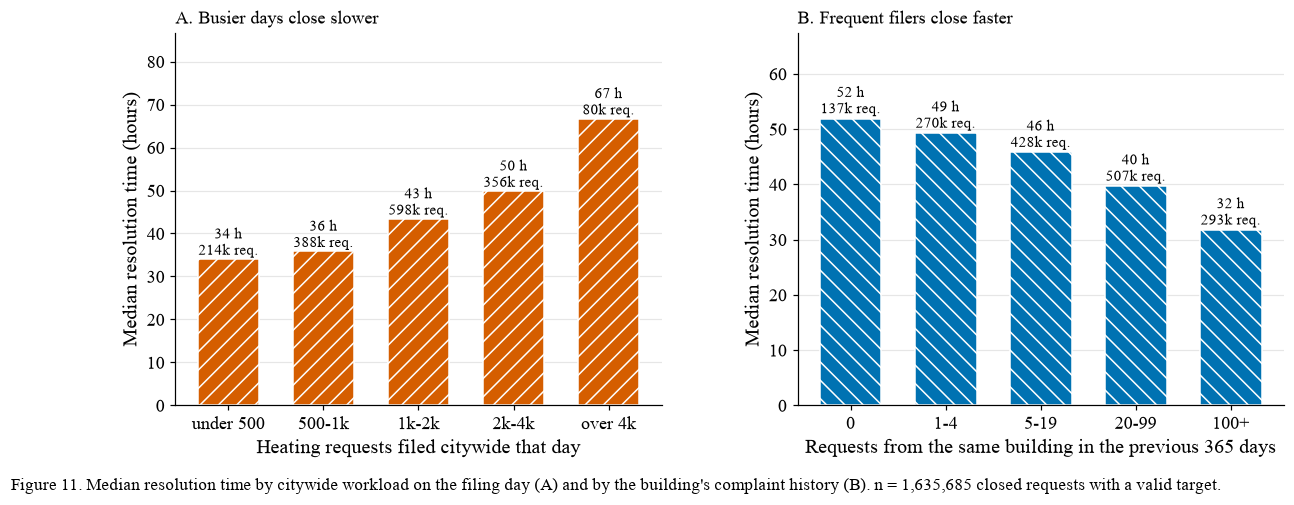

In [81]:
# Figure 11.
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"wspace": 0.28})

for ax, table, colour, hatch, xlabel, title in [
    (ax_a, by_volume, VERMILION, "//", "Heating requests filed citywide that day", "A. Busier days close slower"),
    (ax_b, by_history, BLUE, "\\\\", "Requests from the same building in the previous 365 days", "B. Frequent filers close faster"),
]:
    labels = table.index.astype(str)
    bars = ax.bar(labels, table["median_hours"], color=colour, hatch=hatch, edgecolor="white", width=0.65)
    for bar, (value, rows) in zip(bars, table[["median_hours", "rows"]].to_numpy()):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.0f} h\n{rows / 1000:,.0f}k req.", ha="center", fontsize=9.5)
    ax.set_ylim(0, table["median_hours"].max() * 1.3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Median resolution time (hours)")
    ax.grid(axis="x", visible=False)
    ax.set_title(title, loc="left", fontsize=12)

add_caption(
    fig,
    "Figure 11. Median resolution time by citywide workload on the filing day (A) and by the building's complaint history (B). "
    f"n = {len(with_target):,} closed requests with a valid target.",
)
fig.savefig(FIG_DIR / "11_workload_and_history.png")
plt.show()

**Reading Figure 11.**
- **(A) Workload.** On quiet days the median is in the low-to-mid 30s of hours; on days with more than 4,000 heating requests it roughly doubles.
  HPD's capacity, not the individual request, sets much of the waiting time.
- **(B) History.** Buildings that complained 100+ times in the previous year close faster than buildings with no history.
  A likely reason (inferred, not tested): repeat buildings often already have an open building-wide complaint, and 28% of all requests close as a duplicate of one (7.9).

**Change made: 6 columns created** (`Created Hour`, `Heat Season`, `Season`, `City Daily Volume`, `Building Same Day`, `Building Prior 365d`).
Hour of day and the heat-season flag each show a weak signal alone (section 7.2); they are created here so a tree model can use them together with workload. `Season` groups October to May across the new year (for example `2023-24`), which `Created Year` splits in two,
and it is the natural unit for a time-based train/test split. No rows were removed.

### 7.11 Weather (next step, not added yet)

The heat-season rule says landlords must heat when it is below 55°F in the day or at any temperature at night, so cold days
should bring more complaints and a heavier HPD workload. The next step is to join **NOAA GHCN-Daily minimum temperature for Central Park
(station USW00094728)** on the request's created date. It needs an outside download, so it is listed under "Not yet decided".

## 8. Shape of the cleaned dataset (so far)

In [82]:
print(f"Raw file:           22,671,531 rows x 44 columns")
print(f"Heating only:       {heating.shape[0]:,} rows x {heating.shape[1]} columns")
print(f"Cleaned so far:     {clean.shape[0]:,} rows x {clean.shape[1]} columns")
print(f"Rows removed since filtering to heating: {heating.shape[0] - clean.shape[0]:,} "
      f"({n_duplicates:,} duplicates + {n_open_dropped:,} open requests + {n_status_dropped} with Status not 'Closed')")
print(f"Rows with a usable target (modelling set): {clean[TARGET].notna().sum():,}")

Raw file:           22,671,531 rows x 44 columns
Heating only:       1,656,653 rows x 44 columns
Cleaned so far:     1,635,869 rows x 36 columns
Rows removed since filtering to heating: 20,784 (3,128 duplicates + 17,654 open requests + 2 with Status not 'Closed')
Rows with a usable target (modelling set): 1,635,685


In [83]:
shape_summary = pd.DataFrame(
    {
        "dtype": clean.dtypes.astype(str),
        "missing rows": clean.isna().sum(),
        "distinct values": clean.nunique(),
    }
)
shape_summary.index.name = "column"
shape_summary

,dtype,missing rows,distinct values
column,,,
Created Date,datetime64[us],0,1558682
Closed Date,datetime64[us],0,553427
Problem Detail (formerly Descriptor),str,1,2
Additional Details,str,0,4
Incident Zip,str,190,207
Incident Address,str,3,99807
Street Name,str,3,5034
City,str,148,89
Resolution Description,str,1639,41


### Where the removed rows went

**Question the figure answers:** *How many heating rows did each cleaning rule remove, and how much of the data is left for modelling?*

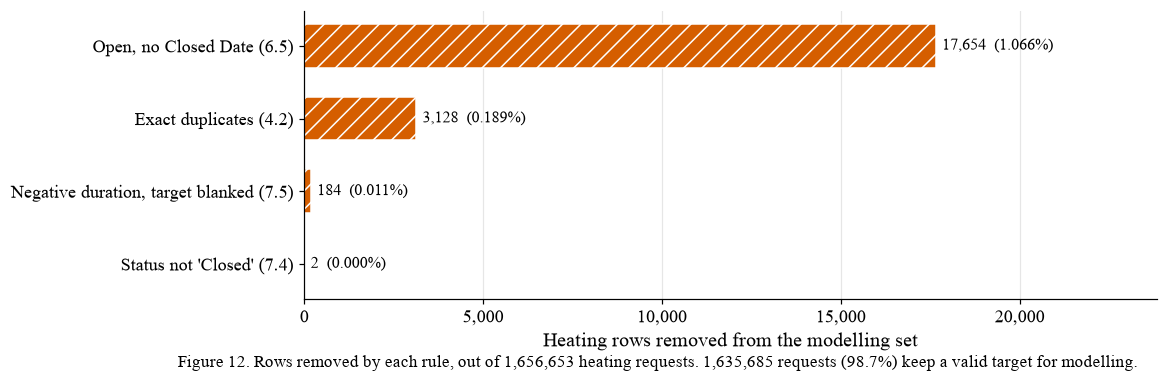

In [84]:
removal = pd.Series(
    {
        "Exact duplicates (4.2)": n_duplicates,
        "Open, no Closed Date (6.5)": n_open_dropped,
        "Negative duration, target blanked (7.5)": int(clean["Is Negative Duration"].sum()),
        "Status not 'Closed' (7.4)": n_status_dropped,
    }
).sort_values()
n_model_rows = int(clean[TARGET].notna().sum())

fig, ax = plt.subplots(figsize=(10, 3.4))
bars = ax.barh(removal.index, removal.values, color=VERMILION, hatch="//", edgecolor="white", height=0.6)
for bar, value in zip(bars, removal.values):
    label = f"{value:,}  ({value / heating.shape[0] * 100:.3f}%)"
    ax.text(value + removal.max() * 0.01, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=10.5)
ax.set_xlim(0, removal.max() * 1.35)
ax.set_xlabel("Heating rows removed from the modelling set")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.grid(axis="y", visible=False)

add_caption(
    fig,
    f"Figure 12. Rows removed by each rule, out of {heating.shape[0]:,} heating requests. "
    f"{n_model_rows:,} requests ({n_model_rows / heating.shape[0] * 100:.1f}%) keep a valid target for modelling.",
)
fig.savefig(FIG_DIR / "12_rows_removed_by_rule.png")
plt.show()

### How the columns got from 44 to 36

| Step | Columns | Change |
|---|---|---|
| Heating only (section 2) | 44 | start |
| ID dropped (4.1) | 43 | -1: `Unique Key` |
| Single-value columns (4.3) | 39 | -4: `Agency`, `Agency Name`, `Park Facility Name`, `Problem` |
| Copy columns (4.4) | 36 | -3: `Intersection Street 1`, `Intersection Street 2`, `Park Borough` |
| `Address Type`, `Location`, `Location Type` (4.5 to 4.7) | 33 | -3 |
| Completely empty (6.2) | 24 | -9 |
| Over 30% missing (6.3) | 21 | -3: `Cross Street 1`, `Cross Street 2`, `Landmark` |
| Open requests dropped (6.5) | 21 | no column change; 17,654 rows removed |
| Resolution time created (7.1) | 22 | +1: `Resolution Hours` |
| Calendar fields created (7.2) | 25 | +3: `Created Year`, `Created Month`, `Created Weekday` |
| Case variants unified (7.3) | 25 | no column change |
| `Status` checked against `Closed Date` (7.4) | 24 | -1: `Status`; 2 rows removed |
| Negative and zero targets (7.5) | 26 | +2: `Is Negative Duration`, `Is Instant Close` |
| Long tail (7.6) | 28 | +2: `Slow Over 72h`, `Resolution Hours Capped` |
| Placeholders to blank (7.7) | 28 | no column change |
| Building ID (7.8) | 29 | +1: `Building ID` |
| Outcome category (7.9) | 30 | +1: `Outcome (EDA only)` |
| Workload, history, calendar (7.10) | 36 | +6: `Created Hour`, `Heat Season`, `Season`, `City Daily Volume`, `Building Same Day`, `Building Prior 365d` |

Rows went from 1,656,653 to 1,635,869 (3,128 exact duplicates, 17,654 open requests and 2 requests whose `Status` was not `Closed` removed).
184 of those rows have a blank target, so the modelling set is 1,635,685 rows. Still to do: the weather join and the final choice of target form (see "Not yet decided").

## 9. Decision table: every cleaning change

The output of an EDA is a table of decisions (Lecture 4): for each column or issue, what was decided and why.
This table covers every change made so far, in the order it was made, so a reader can pick up the data without asking the authors anything.

| Column / issue | Decision | Because |
|---|---|---|
| Rows from the 260 other complaint categories | keep only `HEAT/HOT WATER`; 22,671,531 rows down to 1,656,653 | the project predicts heating resolution time only; other categories have other agencies and processes. Matching on the upper-cased label keeps the 1,814 rows spelled `Heat/Hot Water`. |
| `Unique Key` | drop the column | a row ID; it also made `duplicated()` return 0 (3,128 without it) |
| Duplicate rows | drop 3,128 exact copies, keep the first | only visible once the ID was removed; 70% came from the mobile app (double-taps); the target distribution did not move |
| `Agency`, `Agency Name`, `Park Facility Name`, `Problem` | drop 4 columns | one value in every row (`Problem` had two spellings but one value once upper-cased) |
| `Intersection Street 1`, `Intersection Street 2`, `Park Borough` | drop 3 columns | identical to `Cross Street 1`, `Cross Street 2` and `Borough` in all 1,653,525 rows |
| `Address Type` | drop the column | `ADDRESS` in 1,653,522 of 1,653,525 rows (99.9998%) |
| `Location` | drop the column | the text `POINT (lon lat)`; equals `Longitude` and `Latitude` to within 5e-12 degrees |
| `Location Type` | drop the column | `RESIDENTIAL BUILDING` in 99.89% of rows; in the rest it only repeats `Problem Detail` |
| `Latitude`, `Longitude`, `X Coordinate (State Plane)`, `Y Coordinate (State Plane)` | strip thousands commas, cast to float64 | stored as text, so `describe()` skipped them (0 numeric columns before, 4 after) |
| `Created Date`, `Closed Date`, `Resolution Action Updated Date` | cast to datetime64 with the exact format | stored as text; text dates sort alphabetically, and the target cannot be computed from text |
| `Incident Zip`, `Council District`, `BBL` | keep as text | labels for a place, not measurements; `Council District` has leading zeros |
| 9 empty columns (`Facility Type`, `Due Date`, `Vehicle Type`, `Taxi Company Borough`, `Taxi Pick Up Location`, `Bridge Highway Name`, `Bridge Highway Direction`, `Road Ramp`, `Bridge Highway Segment`) | drop | 100% missing; leftovers from other 311 complaint types |
| `Cross Street 1`, `Cross Street 2`, `Landmark` | drop | 99.89% missing (over the 30% rule); filled only for requests created 10 Aug to 6 Oct 2023 |
| 17,654 requests with no `Closed Date` | drop the rows | the target is missing, and a target is never imputed. All are `Open` or `In Progress`. 12,212 are from 2026, so the drop removes slow-to-close requests, and borough and problem-type mix barely move. Section 7.4 removes 2 more, so 17,656 in total. |
| Resolution time | create `Resolution Hours` = `Closed Date` minus `Created Date`, in hours | it is the target; median 42.8 h, mean 50.9 h, long right tail |
| Seasonality and time trend | create `Created Year`, `Created Month`, `Created Weekday` from `Created Date` | median resolution time varies with each: Friday and Saturday about 16 h slower than Tuesday; March to May fastest; year shifts (36 h in 2024, 49 h in 2021) |
| `Problem Detail`, `Additional Details` | upper-case and trim to one spelling; the one `Water Supply` value becomes blank | HPD used Title case only for requests created 10 Aug to 6 Oct 2023, so each category was counted twice |
| `Status` vs `Closed Date` | closed = `Status` is `Closed` AND a `Closed Date` exists; drop the 2 `Unspecified` rows that have a date; drop `Status` | nothing confirms those 2 were closed; `Status` is then one value, and it is only known after resolution |
| 184 negative `Resolution Hours` | set to blank, flag `Is Negative Duration`, exclude from the target | closed before created; none is within a minute of zero, so it is not clock noise |
| 107 zero `Resolution Hours` | keep, flag `Is Instant Close` | 0.007% of rows, too few to matter, and not shown to be errors |
| Long tail (443 rows over 30 days, max about 3.9 years, skew about 119) | keep every row; report medians; add `Slow Over 72h` and `Resolution Hours Capped` (99.5th percentile) | the values are real complaints, but a few hundred of them pull the mean |
| `log1p` of the target | use it as the regression target, back-transformed with `expm1` | the spread grows with the level on raw hours (Spearman +0.89) and is flat on the log scale (+0.04); in a time-split test it gave the lowest MAE (22.1 h against 28.2 h on raw hours) and the smallest bias (section 7.6.1) |
| `Borough`, `Police Precinct`, `Community Board` `Unspecified`; zips outside NYC; `BBL` `0000000000`; coordinates outside NYC | set to blank | text and codes standing in for a missing value (no coordinate is outside NYC in this extract) |
| Missing `BBL` (about 0.4%) | create `Building ID` = `BBL`, else address + zip | keeps each building's complaint history |
| `Resolution Description` | map the template sentences to `Outcome (EDA only)`; never a model feature | it is written at closing time, so it is leakage |
| New features | create `Created Hour`, `Heat Season`, `Season`, `City Daily Volume`, `Building Same Day`, `Building Prior 365d` | workload and building history are the strongest signals found (Figure 11) |
| Weather | join NOAA daily minimum temperature next | cold days are the likely driver of workload |
| Modelling set | 1,635,685 rows | 1,656,653 − 3,128 duplicates − 17,656 open or unconfirmed − 184 negative targets |

In [85]:
DROPPED_FROM_RAW = {
    "Unique Key",
    "Agency", "Agency Name", "Park Facility Name", "Problem (formerly Complaint Type)",
    "Intersection Street 1", "Intersection Street 2", "Park Borough",
    "Address Type", "Location", "Location Type",
    "Facility Type", "Due Date", "Vehicle Type", "Taxi Company Borough", "Taxi Pick Up Location",
    "Bridge Highway Name", "Bridge Highway Direction", "Road Ramp", "Bridge Highway Segment",
    "Cross Street 1", "Cross Street 2", "Landmark",
    "Status",  # dropped in 7.4
}
CREATED = {
    "Resolution Hours", "Created Year", "Created Month", "Created Weekday",
    # created in 7.5 to 7.10
    "Is Negative Duration", "Is Instant Close", "Slow Over 72h", "Resolution Hours Capped",
    "Building ID", "Outcome (EDA only)",
    "Created Hour", "Heat Season", "Season", "City Daily Volume", "Building Same Day", "Building Prior 365d",
}

actually_dropped = set(heating.columns) - set(clean.columns)
actually_created = set(clean.columns) - set(heating.columns)

# The table above must match what the notebook really did.
assert actually_dropped == DROPPED_FROM_RAW
assert actually_created == CREATED
# The row counts in the table must match too.
assert len(clean) == heating.shape[0] - n_duplicates - n_open_dropped - n_status_dropped == 1_635_869
assert clean[TARGET].notna().sum() == 1_635_685

print(f"Columns dropped: {len(actually_dropped)}    Columns created: {len(actually_created)}")
print(f"Columns: {heating.shape[1]} - {len(actually_dropped)} + {len(actually_created)} = {clean.shape[1]}")
print(f"Rows: {heating.shape[0]:,} - {n_duplicates:,} duplicates - {n_open_dropped:,} open requests "
      f"- {n_status_dropped} unconfirmed = {clean.shape[0]:,}")
print(f"Modelling rows (valid target): {clean[TARGET].notna().sum():,}")

Columns dropped: 24    Columns created: 16
Columns: 44 - 24 + 16 = 36
Rows: 1,656,653 - 3,128 duplicates - 17,654 open requests - 2 unconfirmed = 1,635,869
Modelling rows (valid target): 1,635,685


### Not yet decided

The table above is complete for the cleaning done in this notebook. These items are still open:

| Column / issue | Why it is open |
|---|---|
| Weather | NOAA daily minimum temperature still has to be downloaded and joined on the created date (7.11) |
| Slow-tail handling | regression uses `log1p(Resolution Hours)` (decided in 7.6.1); still open whether `Slow Over 72h` is a side model or a second output, and whether the cut-off should be 7 days |
| Remaining small gaps (`Incident Zip`, `Council District`, `Police Precinct`, coordinates, under 0.2% each) | left blank for now; simple imputation is allowed under 5% if a model needs complete rows |
| `Closed Date`, `Resolution Description`, `Resolution Action Updated Date`, `Outcome (EDA only)` | only known after resolution, so they must not be model features |

## 10. What drives resolution time

**Question this section answers:** *Which properties of a request, known when it is filed, go with a fast or a slow resolution?*

Every figure uses the cleaned requests with a valid target (`eda` below). Medians are used throughout, because the long tail pulls the mean (section 7.6).
Figures 8 and 11 in section 7 already cover the distribution of the target, citywide workload and building history.

In [86]:
eda = clean.dropna(subset=[TARGET]).copy()
eda["Slow"] = eda["Slow Over 72h"].astype(bool)
print(f"{len(eda):,} requests, median {eda[TARGET].median():.1f} h, {eda['Slow'].mean() * 100:.1f}% slower than 72 h")

1,635,685 requests, median 42.8 h, 21.1% slower than 72 h


### 10.1 Borough

**Question the figure answers:** *Does the borough change how long a request takes?*

In [87]:
by_borough = eda.groupby("Borough")[[TARGET, "Slow"]].agg({TARGET: "median", "Slow": "mean"})
by_borough["rows"] = eda.groupby("Borough").size()
by_borough["Slow"] *= 100
by_borough = by_borough.sort_values(TARGET)
by_borough.round(1)

,Resolution Hours,Slow,rows
Borough,,,
BRONX,36.5,14.6,579430
BROOKLYN,45.4,24.2,441347
STATEN ISLAND,45.9,25.1,18334
MANHATTAN,45.9,24.3,377307
QUEENS,46.9,26.4,219260


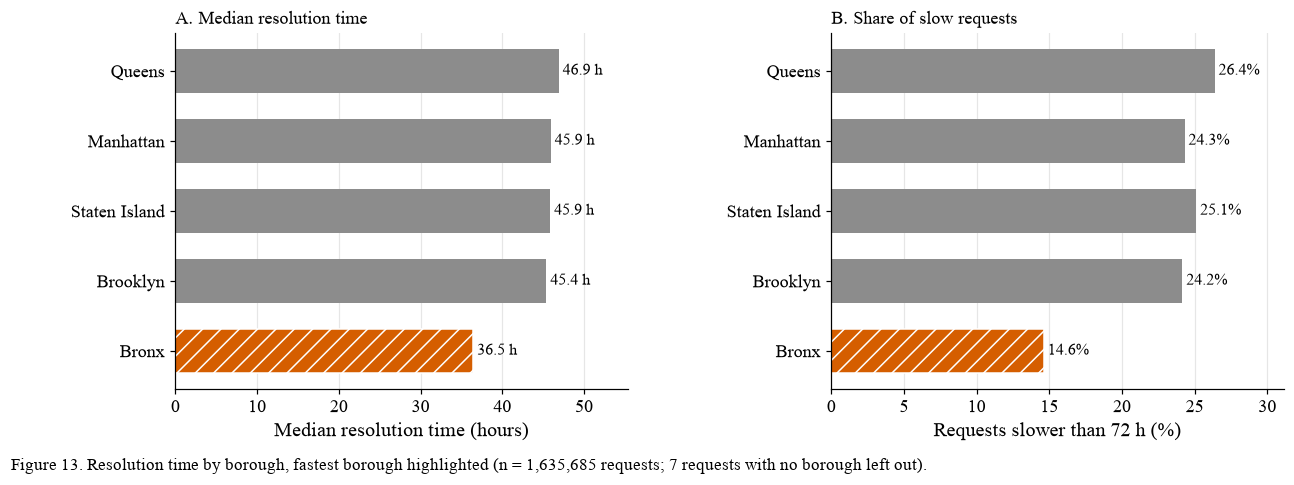

In [88]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"wspace": 0.45})
fastest = by_borough.index[0]

for ax, col, fmt, xlabel, title in [
    (ax_a, TARGET, "{:.1f} h", "Median resolution time (hours)", "A. Median resolution time"),
    (ax_b, "Slow", "{:.1f}%", "Requests slower than 72 h (%)", "B. Share of slow requests"),
]:
    values = by_borough[col]
    colours = [VERMILION if b == fastest else GREY for b in values.index]
    bars = ax.barh([b.title() for b in values.index], values, color=colours, height=0.62)
    bars[0].set_hatch("//")
    bars[0].set_edgecolor("white")
    for bar, value in zip(bars, values):
        ax.text(value + values.max() * 0.01, bar.get_y() + bar.get_height() / 2, fmt.format(value), va="center", fontsize=10.5)
    ax.set_xlim(0, values.max() * 1.18)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.set_title(title, loc="left", fontsize=12)

add_caption(fig, f"Figure 13. Resolution time by borough, fastest borough highlighted (n = {len(eda):,} requests; "
                 f"{eda['Borough'].isna().sum()} requests with no borough left out).")
fig.savefig(FIG_DIR / "13_borough.png")
plt.show()

**Reading Figure 13.** The Bronx is the clear exception. Its median is 36.5 h and only 14.6% of its requests take longer than 72 h,
while the other four boroughs sit close together at 45 to 47 h and 24 to 26% slow. The Bronx is also the borough with the most requests (579,430),
so being busy does not slow a borough down on its own. Borough is worth keeping as a feature, and a Bronx flag captures most of its effect.

### 10.2 Day of the week and hour of the day

**Question the figure answers:** *When during the week is a request filed if it is going to wait longest?*

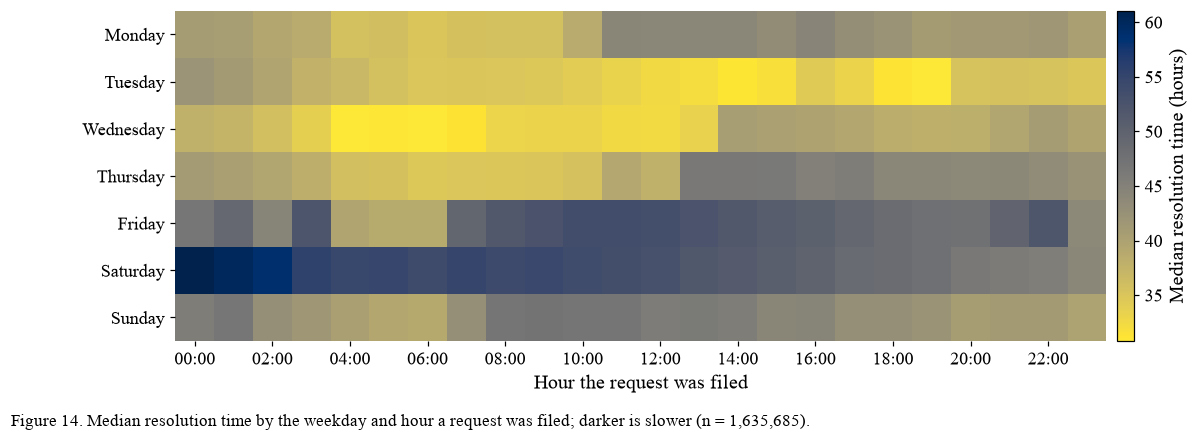

Created Weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
min,35.0,30.8,30.8,34.7,38.7,44.0,38.9
max,44.3,41.9,40.8,46.4,53.7,61.0,47.1


In [89]:
weekday_hour = eda.pivot_table(index="Created Weekday", columns="Created Hour", values=TARGET, aggfunc="median").reindex(WEEKDAY_ORDER)

fig, ax = plt.subplots(figsize=(13, 3.9))
image = ax.imshow(weekday_hour.values, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAY_ORDER)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hour the request was filed")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
bar = fig.colorbar(image, ax=ax, pad=0.01)
bar.set_label("Median resolution time (hours)")

add_caption(fig, f"Figure 14. Median resolution time by the weekday and hour a request was filed; darker is slower (n = {len(eda):,}).", y=-0.06)
fig.savefig(FIG_DIR / "14_weekday_hour.png")
plt.show()

weekday_hour.agg(["min", "max"], axis=1).round(1).T

**Reading Figure 14.** Requests filed on Tuesday and Wednesday close fastest (about 31 h at best), and those filed late on Friday and on Saturday wait longest
(up to about 61 h for Saturday just after midnight). A likely reason, not tested here, is that a request filed just before the weekend waits for
weekday inspection staff. The weekday matters far more than the hour: within a single day the median moves by about 10 to 17 hours.

### 10.3 Over time

**Question the figure answers:** *Does resolution time rise and fall with the number of complaints from season to season?*

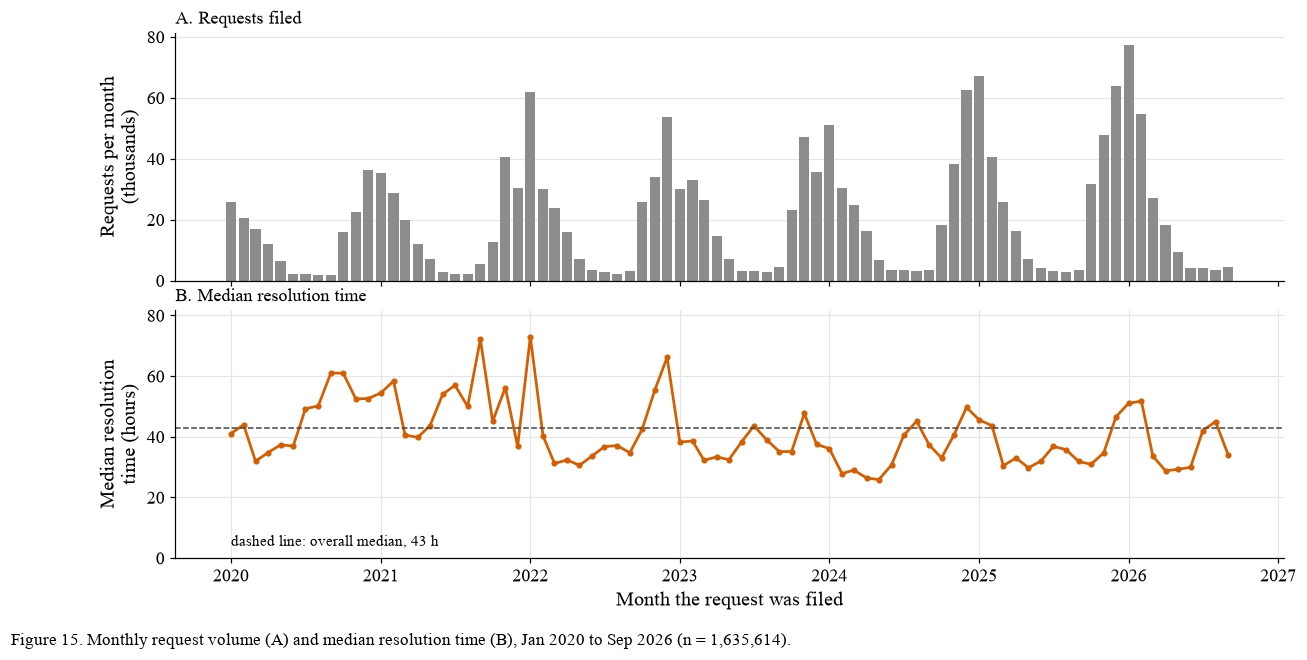

Correlation of monthly volume with monthly median time: 0.30


,median hours,requests
Created Date,,
2022-01-01,72.9,61784
2021-09-01,72.2,5329
2022-12-01,66.2,53686
2020-09-01,61.0,1921
2020-10-01,61.0,15928


In [90]:
monthly = eda.set_index("Created Date").resample("MS").agg({TARGET: "median", "Slow": "size"})
monthly.columns = ["median hours", "requests"]
monthly = monthly[(monthly["requests"] > 0) & (monthly.index < "2026-10-01")]  # the data stops on 1 Oct 2026

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(13, 6.2), sharex=True, gridspec_kw={"hspace": 0.12})
ax_a.bar(monthly.index, monthly["requests"] / 1000, width=25, color=GREY)
ax_a.set_ylabel("Requests per month\n(thousands)")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Requests filed", loc="left", fontsize=12)

ax_b.plot(monthly.index, monthly["median hours"], color=VERMILION, linewidth=1.8, marker="o", markersize=3)
ax_b.axhline(eda[TARGET].median(), color="#444444", linestyle="--", linewidth=1)
ax_b.text(monthly.index[0], 4, f"dashed line: overall median, {eda[TARGET].median():.0f} h", fontsize=10)
ax_b.set_ylim(0, monthly["median hours"].max() * 1.12)
ax_b.set_ylabel("Median resolution\ntime (hours)")
ax_b.set_xlabel("Month the request was filed")
ax_b.set_title("B. Median resolution time", loc="left", fontsize=12)

add_caption(fig, f"Figure 15. Monthly request volume (A) and median resolution time (B), Jan 2020 to Sep 2026 (n = {int(monthly["requests"].sum()):,}).", y=0.0)
fig.savefig(FIG_DIR / "15_monthly_trend.png")
plt.show()

print(f"Correlation of monthly volume with monthly median time: {monthly['requests'].corr(monthly['median hours']):.2f}")
monthly.sort_values("median hours", ascending=False).head(5).round(1)

**Reading Figure 15.** Complaints follow the heat season every year, from about 2,000 a month in summer to a peak of about 77,000 in January 2026.
Resolution time rises with the busiest winters (72.9 h in January 2022 and 66.2 h in December 2022), but the monthly correlation with volume is only 0.30,
because summer months with few requests give noisy medians (for example 72.2 h in September 2021 from 5,329 requests). Since 2023 the medians have mostly stayed
between 25 and 52 h. October 2026 is left out because the data stops on 1 October. The shift between years supports a time-based train/test split.

### 10.4 What the request says

**Question the figure answers:** *Do building-wide outages and no-heat requests close at a different speed from apartment-only or hot-water requests?*

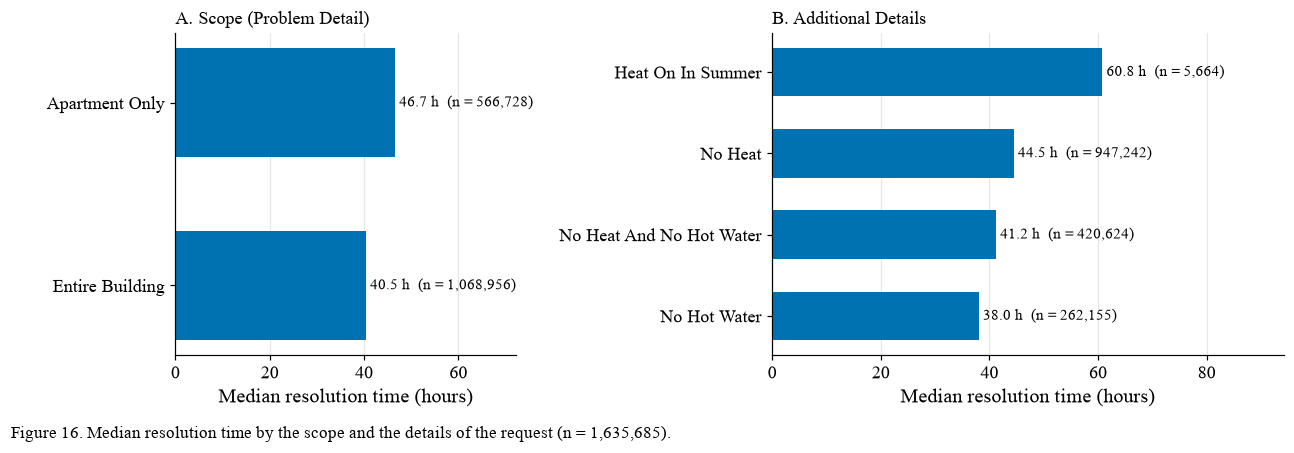

In [91]:
scope = eda.groupby(DETAIL_COL)[TARGET].agg(rows="size", median_hours="median")
details = eda.groupby(EXTRA_COL)[TARGET].agg(rows="size", median_hours="median")

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.5], "wspace": 0.6})
for ax, table, title in [(ax_a, scope.sort_values("median_hours"), "A. Scope (Problem Detail)"),
                         (ax_b, details.sort_values("median_hours"), "B. Additional Details")]:
    bars = ax.barh([s.title() for s in table.index], table["median_hours"], color=BLUE, height=0.6)
    for bar, (value, rows) in zip(bars, table[["median_hours", "rows"]].to_numpy()):
        ax.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f} h  (n = {int(rows):,})", va="center", fontsize=10)
    ax.set_xlim(0, table["median_hours"].max() * 1.55)
    ax.set_xlabel("Median resolution time (hours)")
    ax.grid(axis="y", visible=False)
    ax.set_title(title, loc="left", fontsize=12)

add_caption(fig, f"Figure 16. Median resolution time by the scope and the details of the request (n = {len(eda):,}).", y=-0.06)
fig.savefig(FIG_DIR / "16_request_content.png")
plt.show()

**Reading Figure 16.** Building-wide requests close faster than apartment-only ones (40.5 h against 46.7 h), and hot-water-only requests are the fastest
(38.0 h). `Heat On In Summer` is the slowest group (60.8 h), but it is small (5,664 requests). Both columns are known at filing time, so both are usable features.

### 10.5 How requests end (EDA only)

**Question the figure answers:** *Which closing outcomes take longest?* This uses `Outcome (EDA only)`, which is written at closing time,
so it explains the data but must never be a model feature.

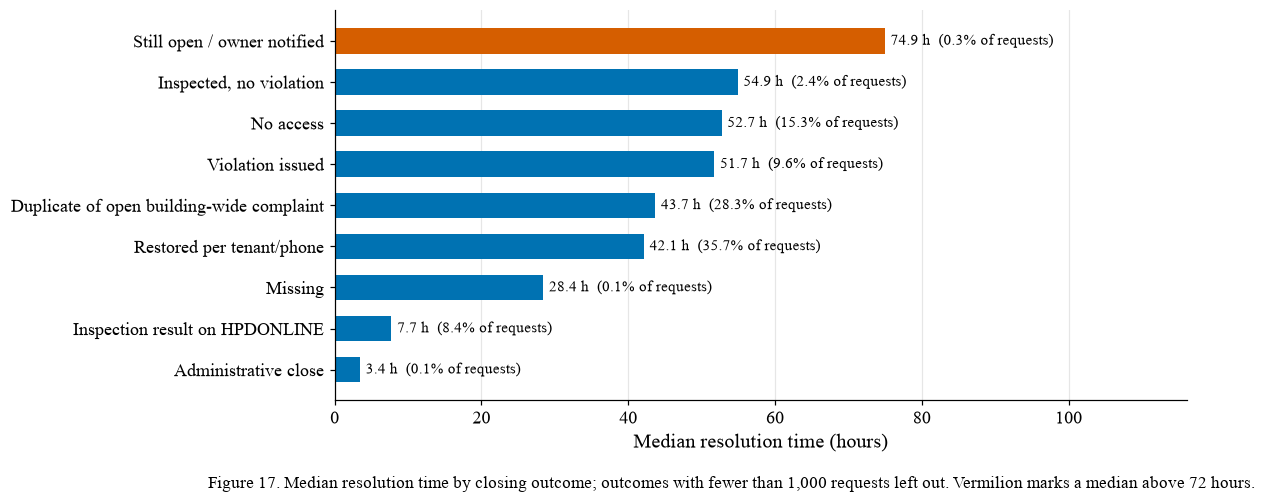

In [92]:
outcomes = eda.groupby("Outcome (EDA only)")[TARGET].agg(rows="size", median_hours="median")
outcomes = outcomes[outcomes["rows"] >= 1000].sort_values("median_hours")
outcomes["share (%)"] = outcomes["rows"] / len(eda) * 100

fig, ax = plt.subplots(figsize=(10, 4.6))
colours = [VERMILION if v > 72 else BLUE for v in outcomes["median_hours"]]
bars = ax.barh(outcomes.index, outcomes["median_hours"], color=colours, height=0.62)
for bar, (value, share) in zip(bars, outcomes[["median_hours", "share (%)"]].to_numpy()):
    ax.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f} h  ({share:.1f}% of requests)", va="center", fontsize=10)
ax.set_xlim(0, outcomes["median_hours"].max() * 1.55)
ax.set_xlabel("Median resolution time (hours)")
ax.grid(axis="y", visible=False)

add_caption(fig, "Figure 17. Median resolution time by closing outcome; outcomes with fewer than 1,000 requests left out. "
                 "Vermilion marks a median above 72 hours.")
fig.savefig(FIG_DIR / "17_outcomes.png")
plt.show()

**Reading Figure 17.** Most requests end in one of two ways: the tenant or a phone check confirms heat was restored (35.7%, 42.1 h), or the request is closed as a
duplicate of an open building-wide complaint (28.3%, 43.7 h). Requests where the inspector could not get in (15.3%) or issued a violation (9.6%) take about 10 hours longer.
Requests that point to the inspection result on HPDONLINE close in 7.7 h. This shows that the slow cases are the ones needing a site visit, but the outcome is only known
after closing, so it stays out of every model.

### 10.6 Which features move together with resolution time

**Question the figure answers:** *Of the features known at filing time, which ones have the strongest relationship with resolution time?*

Spearman's rank correlation is used, because the target is skewed and the relationships are not straight lines.
It is computed as the ordinary correlation of the ranks, which gives the same number without needing SciPy.

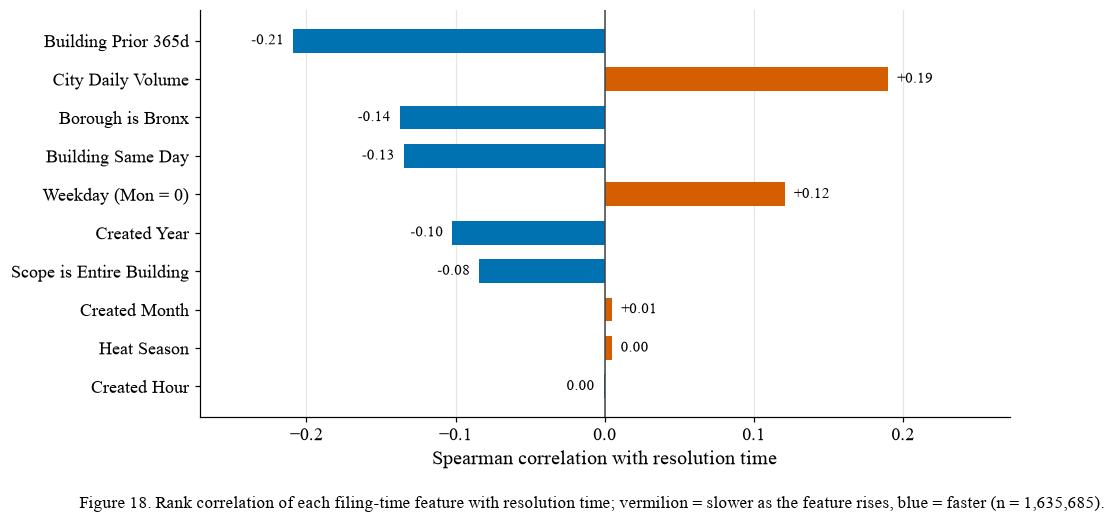

,Spearman
Building Prior 365d,-0.209
City Daily Volume,0.190
Borough is Bronx,-0.138
Building Same Day,-0.135
Weekday (Mon = 0),0.121
Created Year,-0.102
Scope is Entire Building,-0.084
Created Month,0.005
Heat Season,0.005
Created Hour,-0.001


In [93]:
features = pd.DataFrame(
    {
        "Building Prior 365d": eda["Building Prior 365d"],
        "City Daily Volume": eda["City Daily Volume"],
        "Building Same Day": eda["Building Same Day"],
        "Borough is Bronx": (eda["Borough"] == "BRONX").astype(int),
        "Weekday (Mon = 0)": eda["Created Date"].dt.dayofweek,
        "Created Hour": eda["Created Hour"],
        "Created Month": eda["Created Month"],
        "Created Year": eda["Created Year"],
        "Scope is Entire Building": (eda[DETAIL_COL] == "ENTIRE BUILDING").astype(int),
        "Heat Season": eda["Heat Season"].astype(int),
    }
)
ranks = features.rank()
spearman = ranks.corrwith(eda[TARGET].rank()).sort_values(key=abs)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
colours = [VERMILION if v > 0 else BLUE for v in spearman]
bars = ax.barh(spearman.index, spearman.values, color=colours, height=0.62)
for bar, value in zip(bars, spearman.values):
    ax.text(value + (0.006 if value >= 0 else -0.006), bar.get_y() + bar.get_height() / 2, f"{value:+.2f}" if abs(value) >= 0.005 else "0.00",
            va="center", ha="left" if value >= 0 else "right", fontsize=10)
ax.axvline(0, color="#444444", linewidth=1)
limit = spearman.abs().max() * 1.3
ax.set_xlim(-limit, limit)
ax.set_xlabel("Spearman correlation with resolution time")
ax.grid(axis="y", visible=False)

add_caption(fig, f"Figure 18. Rank correlation of each filing-time feature with resolution time; vermilion = slower as the feature rises, "
                 f"blue = faster (n = {len(eda):,}).")
fig.savefig(FIG_DIR / "18_feature_correlation.png")
plt.show()
spearman.round(3).to_frame("Spearman")[::-1]

**Reading Figure 18.** The strongest single signals are building history (−0.21: frequent-filer buildings close faster) and citywide workload (+0.19: busy days are slower),
followed by the Bronx (−0.14), same-day complaints from the same building (−0.13) and the weekday (+0.12). Month, heat season and hour are close to 0 on their own.
No feature is strong alone (all |ρ| ≤ 0.21), so a model has to combine them, which points to a tree-based model, with a logistic regression as the baseline.

### 10.7 Month and hour together

**Question the figure answers:** *Which combinations of filing month and hour have the longest median resolution time?*

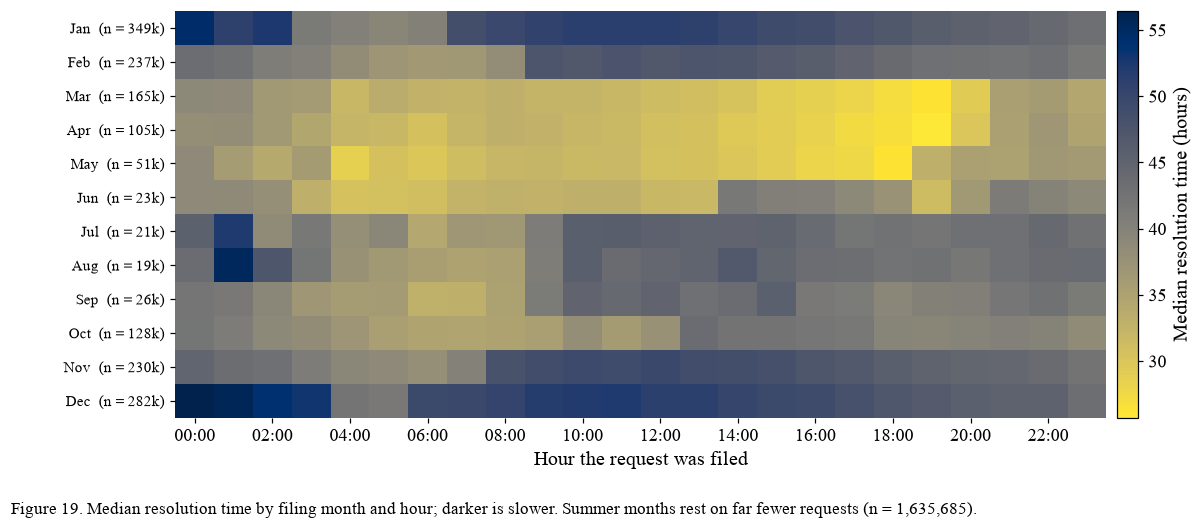

In [94]:
month_hour = eda.pivot_table(index="Created Month", columns="Created Hour", values=TARGET, aggfunc="median")
month_rows = eda.groupby("Created Month").size()

fig, ax = plt.subplots(figsize=(13, 4.8))
image = ax.imshow(month_hour.values, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(12))
ax.set_yticklabels([f"{MONTH_NAMES[m - 1]}  (n = {month_rows[m] / 1000:,.0f}k)" for m in month_hour.index], fontsize=10)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hour the request was filed")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
colour_bar = fig.colorbar(image, ax=ax, pad=0.01)
colour_bar.set_label("Median resolution time (hours)")

add_caption(fig, f"Figure 19. Median resolution time by filing month and hour; darker is slower. Summer months rest on far fewer requests (n = {len(eda):,}).", y=-0.05)
fig.savefig(FIG_DIR / "19_month_hour.png")
plt.show()

**Reading Figure 19.** The month sets the level: December and January are dark across the whole day, March to May light.
The hour matters inside that: requests filed between midnight and 3 am in December and January are the slowest of all (about 55 h),
and March to May requests filed in the late afternoon (16:00 to 19:00) are the fastest (under 30 h). The summer rows rest on few requests.

### 10.8 When requests are filed, and how that compares with when they are slow

**Question the figure answers:** *At which weekday and hour do most heating requests arrive?* All heating requests except exact duplicates
are counted, including the open ones, because an open request is still a submitted request.

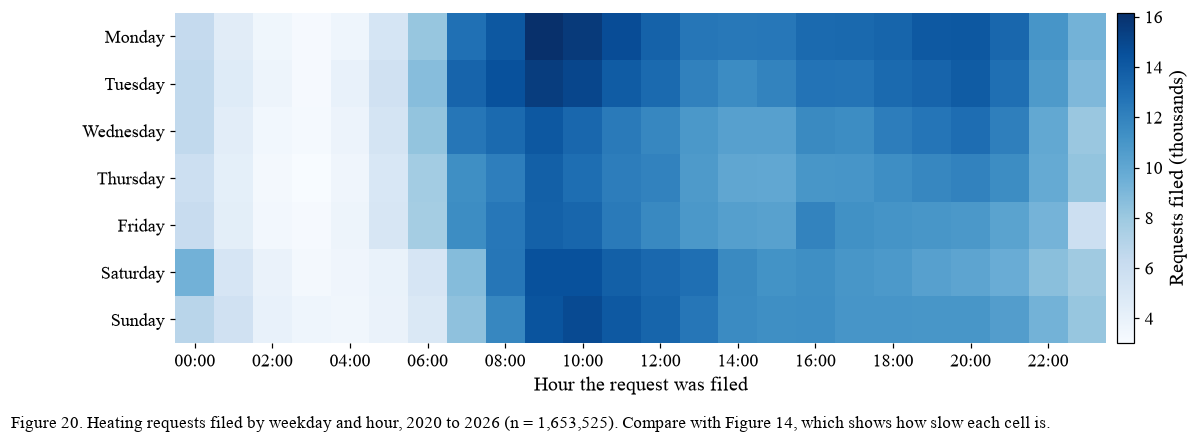

Busiest cell: Monday at 09:00 with 16,161 requests


In [95]:
submitted = history["Created Date"]
volume_grid = pd.crosstab(submitted.dt.dayofweek, submitted.dt.hour)
volume_grid.index = WEEKDAY_ORDER

fig, ax = plt.subplots(figsize=(13, 3.9))
image = ax.imshow(volume_grid.values / 1000, aspect="auto", cmap="Blues")
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAY_ORDER)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hour the request was filed")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
colour_bar = fig.colorbar(image, ax=ax, pad=0.01)
colour_bar.set_label("Requests filed (thousands)")

add_caption(fig, f"Figure 20. Heating requests filed by weekday and hour, 2020 to 2026 (n = {len(history):,}). Compare with Figure 14, which shows how slow each cell is.", y=-0.06)
fig.savefig(FIG_DIR / "20_submissions_weekday_hour.png")
plt.show()

busiest = volume_grid.stack().idxmax()
print(f"Busiest cell: {busiest[0]} at {busiest[1]:02d}:00 with {volume_grid.stack().max():,} requests")

**Reading Figure 20.** Requests peak between 8:00 and 11:00, and Monday and Tuesday mornings are the busiest cells (about 16,000 requests
at 9:00 on Monday). Volume and slowness do not line up: Friday is one of the quieter days, yet Friday and Saturday requests are the slowest
(Figure 14), while busy Tuesday is fast. This points at inspection staffing over the weekend rather than raw demand.

### 10.9 Weekday and intake channel

**Question the figure answers:** *Does the way a request is filed (online, phone, mobile app) change the weekday pattern?*

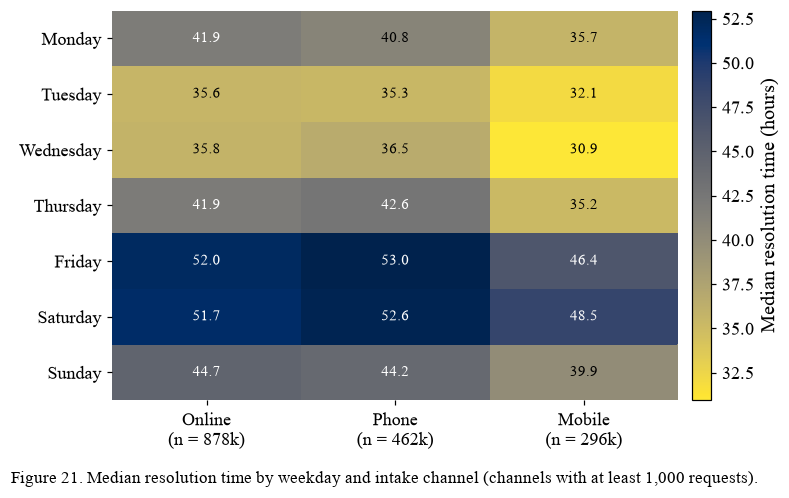

In [96]:
channel_rows = eda[CHANNEL_COL].value_counts()
MAIN_CHANNELS = list(channel_rows[channel_rows >= 1000].index)

weekday_channel = (
    eda[eda[CHANNEL_COL].isin(MAIN_CHANNELS)]
    .pivot_table(index="Created Weekday", columns=CHANNEL_COL, values=TARGET, aggfunc="median")
    .reindex(index=WEEKDAY_ORDER, columns=MAIN_CHANNELS)
)

fig, ax = plt.subplots(figsize=(8, 4.6))
image = ax.imshow(weekday_channel.values, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAY_ORDER)
ax.set_xticks(range(len(MAIN_CHANNELS)))
ax.set_xticklabels([f"{c.title()}\n(n = {channel_rows[c] / 1000:,.0f}k)" for c in MAIN_CHANNELS])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

threshold = np.nanmean(weekday_channel.values)
for row in range(weekday_channel.shape[0]):
    for col in range(weekday_channel.shape[1]):
        value = weekday_channel.iat[row, col]
        text_colour = "white" if value > threshold else "black"
        ax.text(col, row, f"{value:.1f}", ha="center", va="center", fontsize=10, color=text_colour)

colour_bar = fig.colorbar(image, ax=ax, pad=0.02)
colour_bar.set_label("Median resolution time (hours)")
add_caption(fig, f"Figure 21. Median resolution time by weekday and intake channel (channels with at least 1,000 requests).", y=-0.03)
fig.savefig(FIG_DIR / "21_weekday_channel.png")
plt.show()

**Reading Figure 21.** The Friday and Saturday slowdown appears in every channel (about 52 h online and by phone), so it is a property
of the week, not of how people file. Mobile-app requests are the fastest on every day, by about 4 to 6 hours, so `Open Data Channel Type`
is worth keeping as a feature.

### 10.10 Community boards

**Question the figure answers:** *Which community boards are fastest and slowest?* Only boards with at least 1,000 requests are ranked,
so a small board cannot top the list by chance.

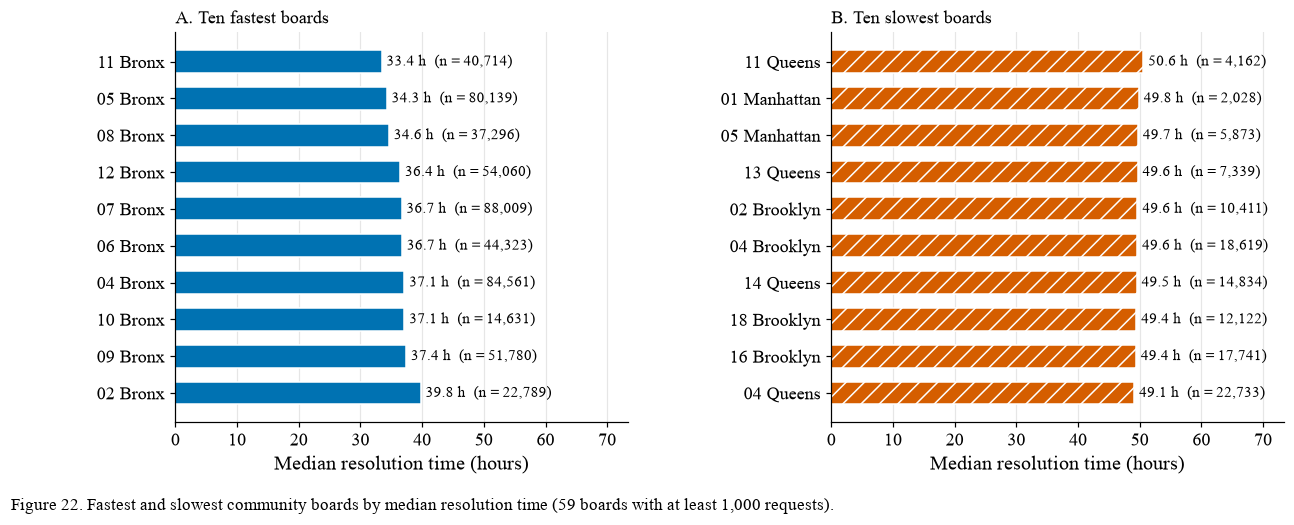

Range across boards: 33.4 h to 50.6 h


In [97]:
MIN_BOARD_ROWS = 1000
board_stats = eda.groupby("Community Board")[TARGET].agg(rows="size", median_hours="median")
board_stats = board_stats[board_stats["rows"] >= MIN_BOARD_ROWS].sort_values("median_hours")
fastest_boards = board_stats.head(10)
slowest_boards = board_stats.tail(10)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True, gridspec_kw={"wspace": 0.45})
for ax, table, colour, hatch, title in [
    (ax_a, fastest_boards.iloc[::-1], BLUE, "", "A. Ten fastest boards"),
    (ax_b, slowest_boards, VERMILION, "//", "B. Ten slowest boards"),
]:
    bars = ax.barh([b.title() for b in table.index], table["median_hours"], color=colour, hatch=hatch, edgecolor="white", height=0.62)
    for bar, (value, rows) in zip(bars, table[["median_hours", "rows"]].to_numpy()):
        ax.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f} h  (n = {int(rows):,})", va="center", fontsize=9.5)
    ax.set_xlabel("Median resolution time (hours)")
    ax.grid(axis="y", visible=False)
    ax.set_title(title, loc="left", fontsize=12)
ax_a.set_xlim(0, board_stats["median_hours"].max() * 1.45)

add_caption(fig, f"Figure 22. Fastest and slowest community boards by median resolution time ({len(board_stats)} boards with at least {MIN_BOARD_ROWS:,} requests).")
fig.savefig(FIG_DIR / "22_community_boards.png")
plt.show()
print(f"Range across boards: {board_stats['median_hours'].min():.1f} h to {board_stats['median_hours'].max():.1f} h")

**Reading Figure 22.** All ten fastest boards are in the Bronx, so much of the board signal is the Bronx effect again. But board medians
still run from about 33 h to 51 h, a wider range than the boroughs (36 to 47 h, Figure 13), and the slowest boards come from three different
boroughs. A finer location feature (community board or zip code) therefore adds information that `Borough` alone loses.

### 10.11 Zip codes: is a busy zip code a slow one? (interactive)

**Question the figure answers:** *Among zip codes with enough requests, does volume go with longer resolution times?* Hover over a point for the zip code.

In [98]:
def most_common(series):
    """Most frequent non-blank value, or NaN when every value is blank."""
    values = series.dropna()
    if values.empty:
        return np.nan
    return values.value_counts().idxmax()


MIN_ZIP_ROWS = 800
zip_stats = eda.groupby("Incident Zip").agg(
    requests=(TARGET, "size"),
    median_hours=(TARGET, "median"),
    borough=("Borough", most_common),
)
zip_stats = zip_stats[zip_stats["requests"] >= MIN_ZIP_ROWS].reset_index()
zip_rho = zip_stats["requests"].rank().corr(zip_stats["median_hours"].rank())

zip_fig = go.Figure()
for borough in BOROUGHS:
    part = zip_stats[zip_stats["borough"] == borough]
    zip_fig.add_trace(
        go.Scatter(
            x=part["requests"],
            y=part["median_hours"],
            mode="markers",
            name=borough.title(),
            marker={"color": BOROUGH_COLOURS[borough], "size": 9, "opacity": 0.8, "line": {"width": 0.5, "color": "white"}},
            customdata=part["Incident Zip"],
            hovertemplate="zip %{customdata}<br>%{x:,} requests<br>median %{y:.1f} h<extra></extra>",
        )
    )
zip_fig.update_layout(
    template="simple_white",
    font={"family": "Times New Roman, DejaVu Serif, serif", "size": 13},
    title=f"Figure 23. Zip codes with at least {MIN_ZIP_ROWS} requests (n = {len(zip_stats)}); Spearman = {zip_rho:+.2f}",
    xaxis={"title": "Heating requests in the zip code (log scale)", "type": "log"},
    yaxis={"title": "Median resolution time (hours)", "rangemode": "tozero"},
    height=520,
    legend_title_text="Borough",
)
zip_fig.write_html(FIG_DIR / "23_zip_volume_vs_time.html", include_plotlyjs="cdn")
zip_fig.show()
print(f"Spearman correlation of zip volume with zip median: {zip_rho:+.2f}")

Spearman correlation of zip volume with zip median: -0.61


**Reading Figure 23.** Busy zip codes are *faster*, not slower (Spearman about −0.6). This matches the building-history result
(Figure 11): areas that file many complaints have many buildings with an open building-wide complaint, and requests there are often
closed as duplicates. It is the opposite of the citywide-workload effect, where a busy *day* is slow.

### 10.12 Map of resolution time

**Question the figure answers:** *Where in the city do requests come from, and where are they slowest?*
Every request with coordinates is binned into hexagons about 0.5 km across; hexagons with fewer than 50 requests are left blank.

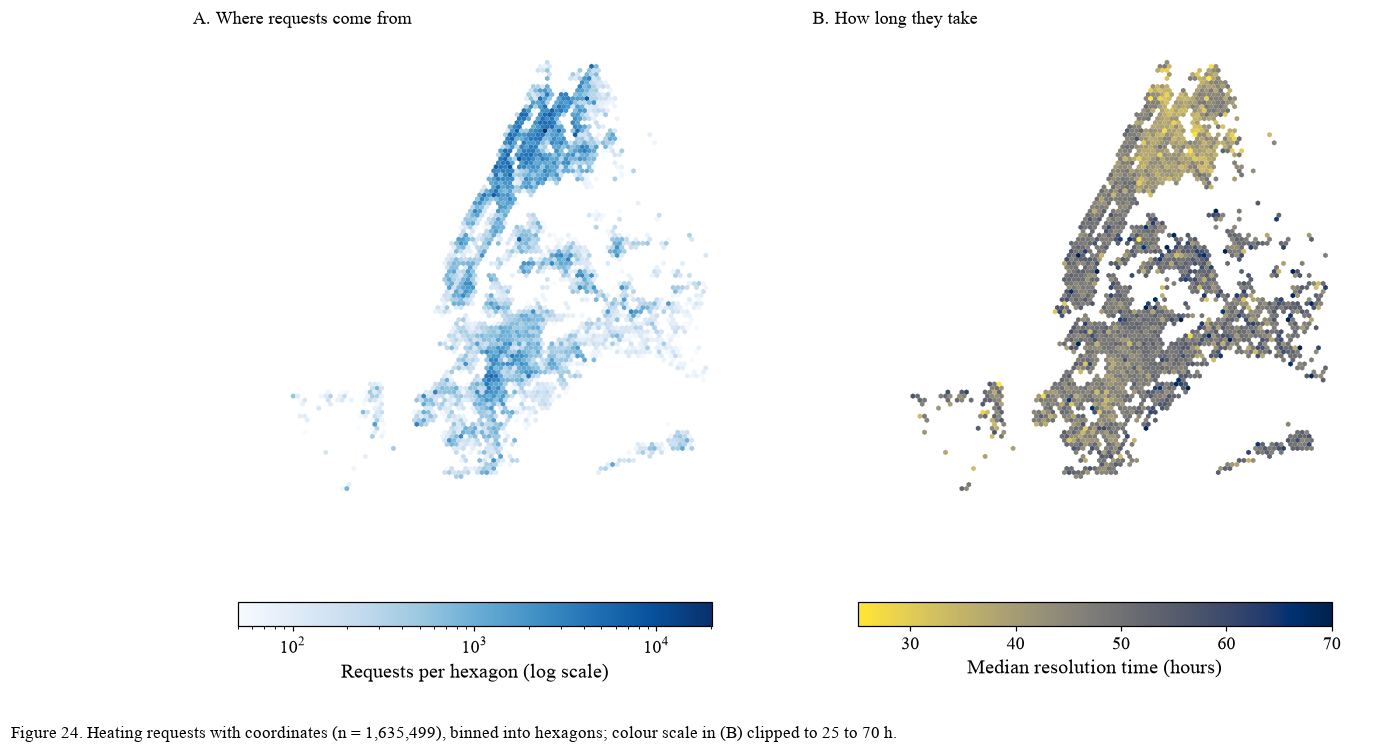

In [99]:
geo = eda.dropna(subset=["Latitude", "Longitude"])
ASPECT = 1 / np.cos(np.radians(40.7))  # one degree of longitude is shorter than one of latitude at NYC

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={"wspace": 0.08})
volume_map = ax_a.hexbin(geo["Longitude"], geo["Latitude"], gridsize=110, bins="log", mincnt=50, cmap="Blues", linewidths=0)
time_map = ax_b.hexbin(
    geo["Longitude"],
    geo["Latitude"],
    C=geo[TARGET],
    reduce_C_function=np.median,
    gridsize=110,
    mincnt=50,
    cmap="cividis_r",
    vmin=25,
    vmax=70,
    linewidths=0,
)
for ax, image, label, title in [
    (ax_a, volume_map, "Requests per hexagon (log scale)", "A. Where requests come from"),
    (ax_b, time_map, "Median resolution time (hours)", "B. How long they take"),
]:
    ax.set_aspect(ASPECT)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, loc="left", fontsize=12)
    colour_bar = fig.colorbar(image, ax=ax, orientation="horizontal", pad=0.02, fraction=0.04)
    colour_bar.set_label(label)

add_caption(fig, f"Figure 24. Heating requests with coordinates (n = {len(geo):,}), binned into hexagons; colour scale in (B) clipped to 25 to 70 h.", y=-0.02)
fig.savefig(FIG_DIR / "24_map_hexbin.png")
plt.show()

**Reading Figure 24.** Requests cluster in the Bronx, upper Manhattan and central Brooklyn. The Bronx is the large light area on the
right-hand map (fast, as in Figure 13); Queens, eastern Brooklyn and the Rockaways are darker, with scattered slow hexagons.
Location matters beyond the borough line, which supports coordinates or zip code as model features.

### 10.13 Borough distributions beyond the median

**Question the figure answers:** *Is the Bronx faster across the whole distribution or only at the median, and how precise are the medians?*
The 95% interval for a median uses the binomial order-statistic rule: the interval runs between the order statistics at
n/2 ± 1.96·√n/2.

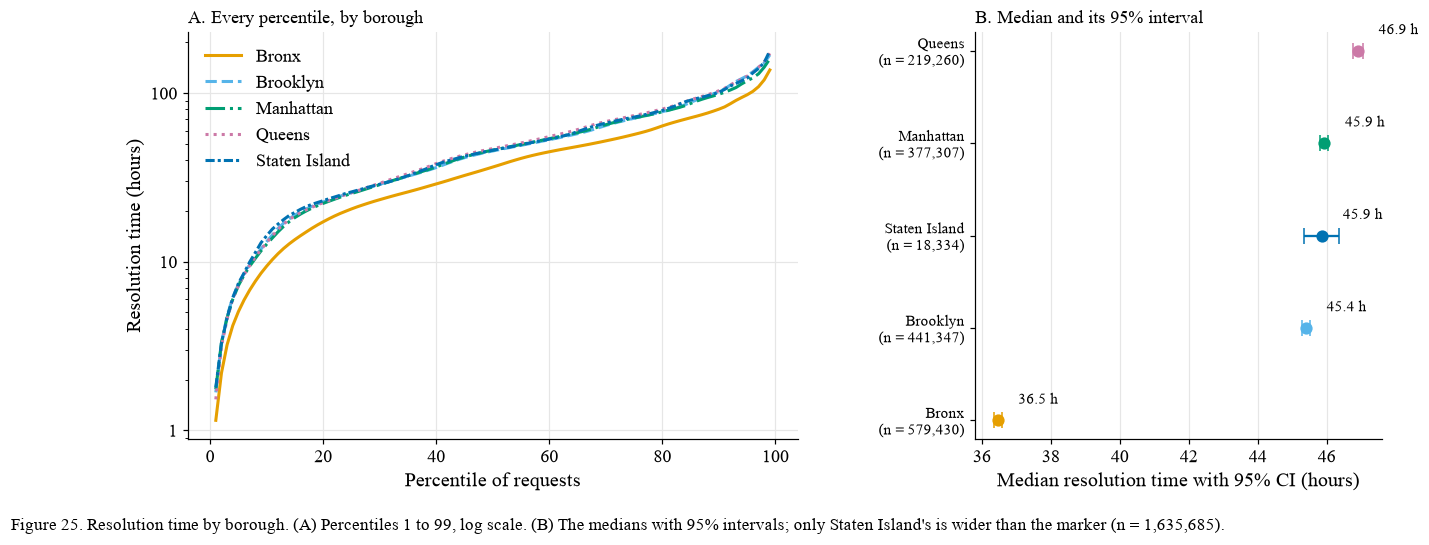

,rows,median (h),95% CI low,95% CI high
borough,,,,
BRONX,579430,36.45,36.34,36.57
BROOKLYN,441347,45.40,45.29,45.51
MANHATTAN,377307,45.93,45.82,46.05
QUEENS,219260,46.91,46.76,47.06
STATEN ISLAND,18334,45.87,45.34,46.36


In [100]:
PERCENTILES = np.arange(1, 100)
borough_rows = []
for borough in BOROUGHS:
    values = np.sort(eda.loc[eda["Borough"] == borough, TARGET].to_numpy())
    n_group = len(values)
    half_width = 1.96 * np.sqrt(n_group) / 2
    lower_index = max(0, int(np.floor(n_group / 2 - half_width)))
    upper_index = min(n_group - 1, int(np.ceil(n_group / 2 + half_width)))
    borough_rows.append(
        {
            "borough": borough,
            "rows": n_group,
            "median (h)": np.median(values),
            "95% CI low": values[lower_index],
            "95% CI high": values[upper_index],
            "quantiles": np.percentile(values, PERCENTILES),
        }
    )
borough_ci = pd.DataFrame(borough_rows).set_index("borough")

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.5, 1], "wspace": 0.35})
for borough in BOROUGHS:
    ax_a.plot(
        PERCENTILES,
        borough_ci.loc[borough, "quantiles"],
        color=BOROUGH_COLOURS[borough],
        linestyle=BOROUGH_STYLES[borough],
        linewidth=2,
        label=borough.title(),
    )
ax_a.set_xlabel("Percentile of requests")
ax_a.set_ylabel("Resolution time (hours)")
ax_a.set_yscale("log")
ax_a.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax_a.legend(loc="upper left")
ax_a.set_title("A. Every percentile, by borough", loc="left", fontsize=12)

ordered = borough_ci.sort_values("median (h)")
positions = np.arange(len(ordered))
errors = [ordered["median (h)"] - ordered["95% CI low"], ordered["95% CI high"] - ordered["median (h)"]]
for pos, borough in zip(positions, ordered.index):
    ax_b.errorbar(
        ordered.loc[borough, "median (h)"],
        pos,
        xerr=[[errors[0][borough]], [errors[1][borough]]],
        fmt="o",
        color=BOROUGH_COLOURS[borough],
        capsize=5,
        markersize=7,
    )
    ax_b.text(ordered.loc[borough, "median (h)"] + 0.6, pos + 0.18, f"{ordered.loc[borough, 'median (h)']:.1f} h", fontsize=10)
ax_b.set_yticks(positions)
ax_b.set_yticklabels([f"{b.title()}\n(n = {ordered.loc[b, 'rows']:,})" for b in ordered.index], fontsize=10)
ax_b.set_xlabel("Median resolution time with 95% CI (hours)")
ax_b.grid(axis="y", visible=False)
ax_b.set_title("B. Median and its 95% interval", loc="left", fontsize=12)

add_caption(fig, f"Figure 25. Resolution time by borough. (A) Percentiles 1 to 99, log scale. (B) The medians with 95% intervals; only Staten Island's is wider than the marker (n = {len(eda):,}).")
fig.savefig(FIG_DIR / "25_borough_distribution.png")
plt.show()

borough_ci.drop(columns="quantiles").round(2)

**Reading Figure 25.** The Bronx line sits below the others at almost every percentile, so it is faster across the whole distribution,
not only at the median. With hundreds of thousands of requests per borough the intervals are a fraction of an hour wide, so the gaps
between boroughs are not sampling noise. Staten Island and Queens differ by only about 1 hour, which matters little in practice.

### 10.14 Borough trends over time

**Question the figure answers:** *Did every borough follow the same rise and fall from season to season?* Months with fewer than 200
requests in a borough are left out, so summer medians do not swing on a handful of requests.

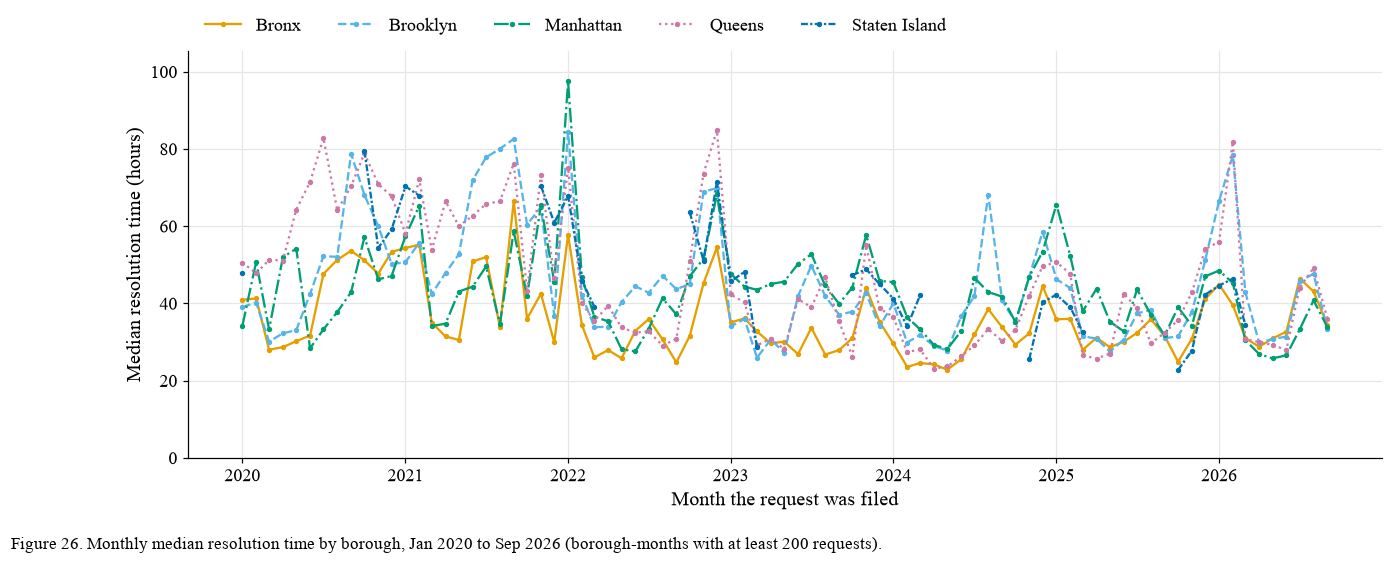

In [101]:
MIN_MONTH_ROWS = 200
monthly_borough = (
    eda[eda["Created Date"] < "2026-10-01"]
    .assign(month=lambda frame: frame["Created Date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["Borough", "month"])[TARGET]
    .agg(rows="size", median_hours="median")
)
monthly_borough = monthly_borough[monthly_borough["rows"] >= MIN_MONTH_ROWS]
all_months = pd.date_range("2020-01-01", "2026-09-01", freq="MS")

fig, ax = plt.subplots(figsize=(14, 4.8))
for borough in BOROUGHS:
    # Reindex to every month so a left-out month breaks the line instead of being bridged.
    series = monthly_borough.loc[borough, "median_hours"].reindex(all_months)
    ax.plot(
        series.index,
        series.values,
        color=BOROUGH_COLOURS[borough],
        linestyle=BOROUGH_STYLES[borough],
        marker="o",
        markersize=2.5,
        linewidth=1.5,
        label=borough.title(),
    )
ax.set_ylim(0, monthly_borough["median_hours"].max() * 1.08)
ax.set_xlabel("Month the request was filed")
ax.set_ylabel("Median resolution time (hours)")
ax.legend(ncol=5, loc="lower left", bbox_to_anchor=(0, 1.0))

add_caption(fig, f"Figure 26. Monthly median resolution time by borough, Jan 2020 to Sep 2026 (borough-months with at least {MIN_MONTH_ROWS} requests).")
fig.savefig(FIG_DIR / "26_monthly_by_borough.png")
plt.show()

**Reading Figure 26.** The boroughs spike together in the same winter months (January 2022, December 2022 and January 2026 are slow
everywhere), which is the citywide workload effect of Figure 11. The Bronx is the lowest or close to the lowest line in most months,
so the borough effect and the time effect add up rather than cancel. Staten Island has gaps because it rarely reaches 200 requests a month.
This shared drift is the main reason the model must be evaluated on a later time period.

### 10.15 How the filing-time features relate to each other

**Question the figure answers:** *Which filing-time features move together, so that a model would see the same signal twice?*
Spearman rank correlation, diverging colours centred on zero.

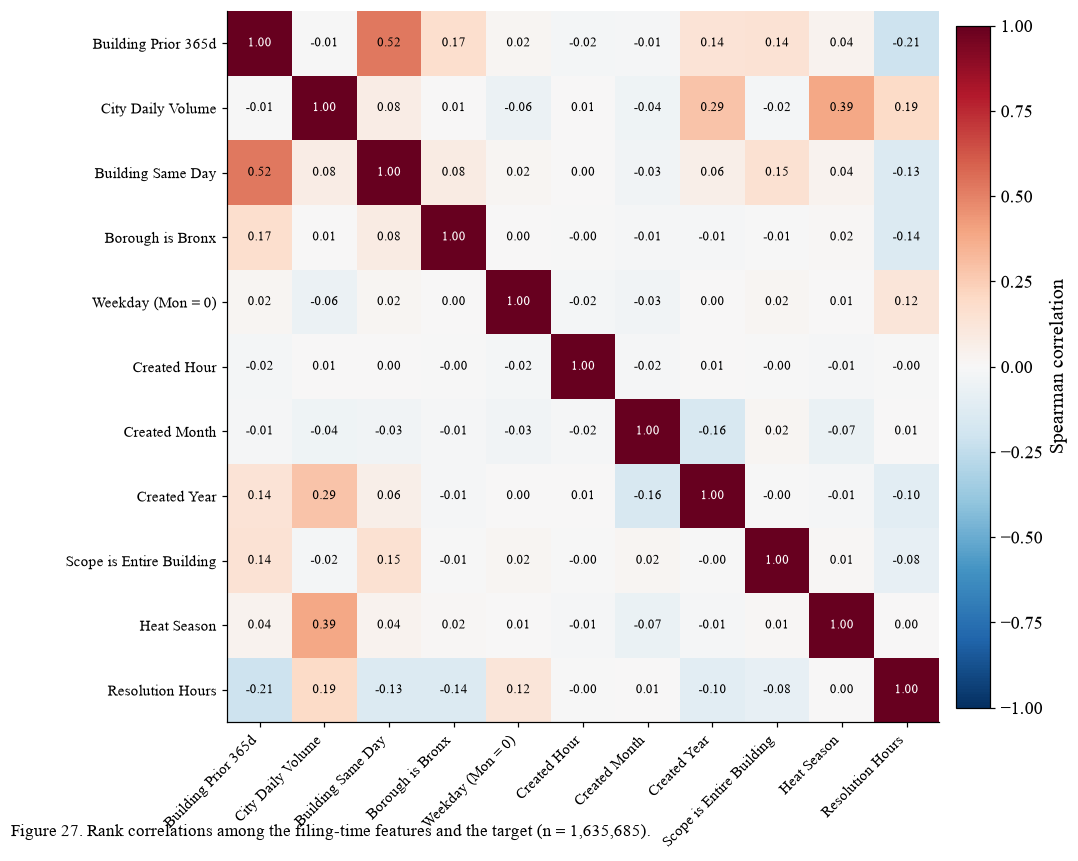

|Spearman|
Building Prior 365d Building Same Day        0.52
City Daily Volume   Heat Season              0.39
                    Created Year             0.29
Building Prior 365d Resolution Hours         0.21
City Daily Volume   Resolution Hours         0.19
Building Prior 365d Borough is Bronx         0.17

In [102]:
matrix_frame = features.copy()
matrix_frame["Resolution Hours"] = eda[TARGET]
corr_matrix = matrix_frame.rank().corr()

fig, ax = plt.subplots(figsize=(10, 8.4))
image = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(corr_matrix)))
ax.set_yticklabels(corr_matrix.index, fontsize=10)
ax.grid(False)
for row in range(len(corr_matrix)):
    for col in range(len(corr_matrix)):
        value = corr_matrix.iat[row, col]
        text_colour = "white" if abs(value) > 0.6 else "black"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=8.5, color=text_colour)
colour_bar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.02)
colour_bar.set_label("Spearman correlation")

add_caption(fig, f"Figure 27. Rank correlations among the filing-time features and the target (n = {len(eda):,}).", y=0.0)
fig.savefig(FIG_DIR / "27_feature_correlation_matrix.png")
plt.show()

pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)).stack()
pairs.abs().sort_values(ascending=False).head(6).round(2).to_frame("|Spearman|")

**Reading Figure 27.** No pair of features is close to a copy of another: the strongest pair is a building's prior-year complaints with
its same-day complaints (0.52), followed by citywide daily volume with the heat season (0.39) and with the year (0.29). Every feature is
also only weakly related to the target on its own (|ρ| ≤ 0.21), so the signal is spread across many features and their interactions,
which favours a tree ensemble over a linear model.

## 11. Interactive dashboard

One interactive view of the main findings. The drop-down at the top filters every panel to one borough, and the title updates with that
borough's request count, median and share of slow requests. Hover over any bar or point for the exact numbers.

The dashboard is also saved as `figures/dashboard.html`, which opens in any browser without Python.
The graded dashboard for the presentation is built in Tableau from the cleaned file exported in section 12; this view is the same story inside the notebook.

In [103]:
SELECTIONS = ["All boroughs"] + BOROUGHS
VOLUME_BANDS = ["under 500", "500-1k", "1k-2k", "2k-4k", "over 4k"]
HISTORY_BANDS = ["0", "1-4", "5-19", "20-99", "100+"]

dash = eda[["Created Date", "Borough", "Created Weekday", "City Daily Volume", "Building Prior 365d", TARGET, "Slow"]].copy()
dash["month"] = dash["Created Date"].dt.to_period("M").dt.to_timestamp()
dash.loc[dash["month"] >= "2026-10-01", "month"] = pd.NaT  # partial month left out of the monthly line only
dash["volume band"] = pd.cut(dash["City Daily Volume"], [0, 500, 1000, 2000, 4000, np.inf], labels=VOLUME_BANDS)
dash["history band"] = pd.cut(dash["Building Prior 365d"], [-1, 0, 4, 19, 99, np.inf], labels=HISTORY_BANDS)


def panel_data(frame):
    """The four aggregates the dashboard draws, for one selection."""
    return {
        "monthly": frame.groupby("month")[TARGET].median(),
        "weekday": frame.groupby("Created Weekday")[TARGET].median().reindex(WEEKDAY_ORDER),
        "volume": frame.groupby("volume band", observed=True)["Slow"].mean().reindex(VOLUME_BANDS) * 100,
        "history": frame.groupby("history band", observed=True)[TARGET].median().reindex(HISTORY_BANDS),
        "title": (f"{len(frame):,} requests  ·  median {frame[TARGET].median():.1f} h  ·  "
                  f"{frame['Slow'].mean() * 100:.1f}% slower than 72 h"),
    }


panels = {name: panel_data(dash if name == "All boroughs" else dash[dash["Borough"] == name]) for name in SELECTIONS}
print("\n".join(f"{name:14s} {p['title']}" for name, p in panels.items()))

All boroughs   1,635,685 requests  ·  median 42.8 h  ·  21.1% slower than 72 h
BRONX          579,430 requests  ·  median 36.5 h  ·  14.6% slower than 72 h
BROOKLYN       441,347 requests  ·  median 45.4 h  ·  24.2% slower than 72 h
MANHATTAN      377,307 requests  ·  median 45.9 h  ·  24.3% slower than 72 h
QUEENS         219,260 requests  ·  median 46.9 h  ·  26.4% slower than 72 h
STATEN ISLAND  18,334 requests  ·  median 45.9 h  ·  25.1% slower than 72 h


In [104]:
fig = make_subplots(
    rows=2, cols=2, vertical_spacing=0.16, horizontal_spacing=0.09,
    subplot_titles=[
        "Median resolution time by month (hours)",
        "Median resolution time by weekday filed (hours)",
        "Share slower than 72 h by citywide requests that day (%)",
        "Median resolution time by building's requests in prior year (hours)",
    ],
)
for k, name in enumerate(SELECTIONS):
    p = panels[name]
    visible = k == 0
    fig.add_trace(go.Scatter(x=p["monthly"].index, y=p["monthly"].values, mode="lines", line={"color": VERMILION, "width": 2},
                             name="monthly", visible=visible, hovertemplate="%{x|%b %Y}: %{y:.1f} h<extra></extra>"), 1, 1)
    fig.add_trace(go.Bar(x=[d[:3] for d in WEEKDAY_ORDER], y=p["weekday"].values, marker_color=BLUE,
                         name="weekday", visible=visible, hovertemplate="%{x}: %{y:.1f} h<extra></extra>"), 1, 2)
    fig.add_trace(go.Bar(x=VOLUME_BANDS, y=p["volume"].values, marker_color=VERMILION,
                         name="workload", visible=visible, hovertemplate="%{x}: %{y:.1f}%<extra></extra>"), 2, 1)
    fig.add_trace(go.Bar(x=HISTORY_BANDS, y=p["history"].values, marker_color=BLUE,
                         name="history", visible=visible, hovertemplate="%{x} prior requests: %{y:.1f} h<extra></extra>"), 2, 2)

buttons = []
for k, name in enumerate(SELECTIONS):
    visible = [j // 4 == k for j in range(4 * len(SELECTIONS))]
    buttons.append({"label": name.title(), "method": "update",
                    "args": [{"visible": visible}, {"title.text": f"<b>HPD heat complaints, {name.title()}</b><br><sup>{panels[name]['title']}</sup>"}]})

fig.update_layout(
    title={"text": f"<b>HPD heat complaints, All Boroughs</b><br><sup>{panels['All boroughs']['title']}</sup>", "x": 0.01},
    updatemenus=[{"buttons": buttons, "x": 1.0, "xanchor": "right", "y": 1.13, "yanchor": "top", "showactive": True}],
    template="simple_white", font={"family": "Times New Roman, DejaVu Serif, serif", "size": 13},
    height=720, showlegend=False, margin={"t": 120, "l": 60, "r": 30, "b": 50},
)
fig.update_yaxes(rangemode="tozero", gridcolor="#E6E6E6", showgrid=True)
fig.write_html(FIG_DIR / "dashboard.html", include_plotlyjs=True)
fig.show()

**How to read the dashboard.** The top-left panel shows the seasonal cycle and the slow winter of 2021-22. The top-right panel repeats the weekday pattern from section 7.2.
The bottom-left panel shows workload pushing up the share of slow requests, and the bottom-right panel shows frequent-filer buildings closing faster (Figure 11).
Switching boroughs shows whether each pattern holds everywhere or is driven by one borough.

## 12. Save the cleaned data

The cleaned table (one row per closed heating request, with the target, flags and filing-time features) is saved as Parquet
for the modelling step described in `README.md`. The Tableau CSV export is optional, because it is about 500 MB and the
Tableau extract already exists; set `EXPORT_FOR_TABLEAU = True` to rewrite it.

In [105]:
CLEAN_PARQUET = DATA_DIR / "heating_clean_features.parquet"
clean.to_parquet(CLEAN_PARQUET, index=False)
print(f"Wrote {CLEAN_PARQUET}: {len(clean):,} rows x {clean.shape[1]} columns, {CLEAN_PARQUET.stat().st_size / 1e6:,.0f} MB")

Wrote data/heating_clean_features.parquet: 1,635,869 rows x 36 columns, 90 MB


In [106]:
EXPORT_FOR_TABLEAU = False

TABLEAU_COLS = [
    "Created Date", "Closed Date", TARGET, "Resolution Hours Capped", "Slow Over 72h",
    "Is Negative Duration", "Is Instant Close",
    DETAIL_COL, EXTRA_COL, "Open Data Channel Type",
    "Borough", "Incident Zip", "Community Board", "Council District", "Police Precinct", "BBL", "Building ID",
    "Incident Address", "Latitude", "Longitude",
    "Created Year", "Created Month", "Created Weekday", "Created Hour", "Heat Season", "Season",
    "City Daily Volume", "Building Same Day", "Building Prior 365d", "Outcome (EDA only)",
]
TABLEAU_CSV = DATA_DIR / "heating_clean_tableau.csv"

if EXPORT_FOR_TABLEAU:
    clean[TABLEAU_COLS].to_csv(TABLEAU_CSV, index=False, date_format="%Y-%m-%d %H:%M:%S")
    print(f"Wrote {TABLEAU_CSV}: {len(clean):,} rows x {len(TABLEAU_COLS)} columns, {TABLEAU_CSV.stat().st_size / 1e6:,.0f} MB")